In [14]:
import csv
from traceback import print_exc

import numpy as np
np.int=int
import pandas as pd
import os
import matplotlib.pyplot as plt

<h2>
SNe True Ages

In [57]:
import pandas as pd
import csv
import numpy as np

def calculate_sn_ages(params_file, spectra_mjd_file, output_file):
    """
    Calculates the age of a supernova at the time each spectrum was taken.

    The age is determined by subtracting the peak MJD (Modified Julian Date)
    from the parameter file from the observation MJD in the spectra file.
    This script also includes the uncertainty for the peak MJD and the Heliocentric Redshift.

    Args:
        params_file (str): Path to the supernova parameters data file.
        spectra_mjd_file (str): Path to the spectra MJD data file.
        output_file (str): Path for the output text file.
    """
    try:
        # --- 1. Load the Supernova Parameters File ---
        # Read the file, skipping comments, using whitespace as a delimiter.
        # Columns mapped: 0->SN_name, 2->mjd_max, 3->mjd_max_err, 1->zhel
        param_cols = ['SN_name', 'zhel', 'mjd_max', 'mjd_max_err']
        params_data = pd.read_csv(
            params_file,
            comment='#',
            delim_whitespace=True,
            header=None,
            usecols=[0, 1, 2, 3],
            names=param_cols
        )

        # --- 2. Create a lookup map for peak times, error, and redshift ---
        # We normalize the names by adding an "sn" prefix to match the format
        # in the spectra file (e.g., '1993ac' becomes 'sn1993ac').
        mjd_map = {}
        for _, row in params_data.iterrows():
            if row['mjd_max'] < 99990:  # Filter out invalid MJD values
                # Normalize name logic
                if str(row['SN_name']).startswith('SNF'):
                    name = str(row['SN_name']).lower
                else:
                    name = f"sn{row['SN_name']}"

                # Store MJD, Error, and Redshift
                mjd_map[normalized_name] = {
                    'mjd_max': row['mjd_max'],
                    'mjd_max_err': row['mjd_max_err'],
                    'redshift': row['zhel']
                }

        print(f"Loaded parameters for {len(mjd_map)} unique supernovae.")

        # --- 3. Load the Spectra MJD File ---
        spectra_cols = ['filename', 'mjd_obs']
        spectra_data = pd.read_csv(
            spectra_mjd_file,
            comment='#',
            delim_whitespace=True,
            header=None,
            names=spectra_cols
        )
        print(f"Loaded {len(spectra_data)} spectral observations.")

        # --- 4. Calculate Ages and Prepare Output ---
        results = []
        for _, row in spectra_data.iterrows():
            spectrum_filename = row['filename']
            mjd_obs = row['mjd_obs']

            # Extract the base SN name from the spectrum filename.
            if spectrum_filename.startswith('snf'):
                base_sn_name = spectrum_filename.split('-')[0] + '-' + spectrum_filename.split('-')[1]
            else:
                base_sn_name = spectrum_filename.split('-')[0]

            # Look up the parameters in our map
            # We use .get() to handle case sensitivity slightly better if keys are consistently lower
            param_data = mjd_map.get(base_sn_name.lower())

            if param_data:
                age = mjd_obs - param_data['mjd_max']
                age_unc = param_data['mjd_max_err']
                zhel = param_data['zhel']

                # Append result with redshift
                results.append((
                    spectrum_filename,
                    base_sn_name,
                    f"{age:.4f}",
                    f"{age_unc:.4f}",
                    f"{zhel:.5f}"
                ))
            else:
                results.append((spectrum_filename, base_sn_name, "N/A", "N/A", "N/A"))

        # --- 5. Format and Save the Results to a CSV File ---
        with open(output_file, 'w', newline='') as f:
            writer = csv.writer(f)
            # Create a header including Redshift
            header = ["Filename", "SN_Name", "Age_(days)", "Age_Unc_(days)", "zhel"]
            writer.writerow(header)
            # Write the data rows
            writer.writerows(results)

        print(f"Successfully calculated ages for {len(results)} spectra.")
        print(f"Results saved to '{output_file}'")
        return np.array(results)

    except FileNotFoundError as e:
        print(f"Error: The file could not be found. Details: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

In [60]:
calculated_ages_data = calculate_sn_ages('cfa_supersnid_top20_median/cfasnIa_param.dat', 'cfa_supersnid_top20_median/cfasnIa_mjdspec.dat', 'cfa_supersnid_top20_median/cfa_supersnid_all_spectra_ages.csv')

print((calculated_ages_data[-1]))
print(type(calculated_ages_data))


no_na_count = sum(1 for row in calculated_ages_data if 'N/A' not in row)

print(f"Number of items without N/A: {no_na_count}")


Loaded parameters for 271 unique supernovae.
Loaded 2603 spectral observations.
Successfully calculated ages for 2603 spectra.
Results saved to 'cfa_supersnid_top20_median/cfa_supersnid_all_spectra_ages.csv'
['snf20080720-001-20080801.44-fast.flm' 'snf20080720-001' '7.6400'
 '0.3000' '0.02090']
<class 'numpy.ndarray'>
Number of items without N/A: 1828


/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_68014/3596869013.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params_data = pd.read_csv(
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_68014/3596869013.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  spectra_data = pd.read_csv(


<h2>
SNe Subtype

In [17]:
def append_sn_subtype(calculated_ages_data, classification_file):
    """
    Appends the supernova subtype (Wang class) to the calculated ages data.

    Args:
        calculated_ages_data (np.array): Array of calculated ages data.
        classification_file (str): Path to the SN classification file.

    Returns:
        np.array: The input array with SN subtype (Wang class) appended, or the original array if the classification file is not found.
    """
    try:
        # --- 1. Read the classification file and create a lookup map ---
        subtype_map = {}
        with open(classification_file, 'r') as f:
            # Skip the first 51 lines
            for _ in range(51):
                next(f, None)
            for line in f:
                if len(line) >= 48 and (line.startswith('1') or line.startswith('2') or line.startswith('S')):
                    sn_name = line[:15].strip()
                    if sn_name.startswith('SNF'):
                        normalised_name = sn_name
                    else:
                        normalised_name = f"sn{sn_name}"

                    # b_class = line[41:43].strip() # No longer needed
                    w_class = line[44:48].strip()
                    subtype_map[normalised_name.lower()] = w_class # Store only Wang class
        # print(subtype_map)
        # --- 2. Append the subtype to the calculated ages data ---
        results_with_subtype = []
        for row in calculated_ages_data:
            sn_name_short = str(row[1].strip().lower())
            if sn_name_short.lower() in (k.lower() for k in subtype_map):
                # print(sn_name_short)
                w_class = subtype_map[sn_name_short] # Unpack only Wang class
                results_with_subtype.append(tuple(row) + (w_class,)) # Append only Wang class
            else:
                results_with_subtype.append(tuple(row) + ('N/A',)) # Append single 'N/A'

        return np.array(results_with_subtype)

    except FileNotFoundError:
        print(f"Warning: Classification file not found at '{classification_file}'. Subtypes will not be appended.")
        return calculated_ages_data

data_with_subtypes = append_sn_subtype(calculated_ages_data, '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/sne_classification')


In [18]:
print(data_with_subtypes)

np.sum(data_with_subtypes[:, -1] != 'N/A')

[['sn1993ac-19931016.49-mmt.flm' 'sn1993ac' '7.2900' '1.2000' '0.05030'
  'HV']
 ['sn1993ac-19931020.52-mmt.flm' 'sn1993ac' '11.3200' '1.2000' '0.05030'
  'HV']
 ['sn1993ae-19931213.11-mmt.flm' 'sn1993ae' 'N/A' 'N/A' 'N/A' 'N/A']
 ...
 ['snf20080720-001-20080729.47-fast.flm' 'snf20080720-001' '4.6700'
  '0.3000' '0.02090' 'N']
 ['snf20080720-001-20080730.46-mmt.flm' 'snf20080720-001' '5.6600'
  '0.3000' '0.02090' 'N']
 ['snf20080720-001-20080801.44-fast.flm' 'snf20080720-001' '7.6400'
  '0.3000' '0.02090' 'N']]


np.int64(1985)

<h2>
Signal to noise ratio


In [71]:
from utils.snr_finder_group import analyze_spectrum_dersnr
from utils.snr_methods_comparison import der_snr

In [72]:
spectra_to_analyze_dir = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_extinction_corrected/corrected_spectra'

parameters_file = "cfa_supersnid_top20_median/cfasnIa_param.dat"

output_csv_filename = "snr_analysis_results.csv"

# Loop through each item in the data array to process it
data_with_snr = []

for item in data_with_subtypes:
    spectrum_filename = item[0]
    base_name, extension = os.path.splitext(spectrum_filename)
    modified_base_name = base_name + '_corrected'
    new_filename = modified_base_name + extension
    full_spectrum_path = os.path.join(spectra_to_analyze_dir, new_filename)

    snr_value = 'N/A'  # Default value

    if not os.path.isfile(full_spectrum_path):
        print(f"  > Spectrum file not found: {spectrum_filename}. Skipping.")
    else:
        print(f"Processing {spectrum_filename}...")
        analysis_result = analyze_spectrum_dersnr(
            spectrum_file=full_spectrum_path,
            params_file=parameters_file
        )

        if analysis_result and 'snr' in analysis_result:
            snr_value = analysis_result['snr']
            print(f"  > Success! S/N = {snr_value}")
        else:
            print(f"  > Failed to calculate S/N for {spectrum_filename}.")

    # Create the new, appended item
    new_item = np.append(item, snr_value)

    # Append this new item to your results list
    data_with_snr.append(new_item)
#     print(new_item)
print("\n--- Analysis Complete ---")
print("Updated data_with_subtypes array with appended S/N values:")

# # Pretty-print the final result
# for row in data_with_snr:
#     print(row)

Processing sn1993ac-19931016.49-mmt.flm...
  > Success! S/N = 26.31
Processing sn1993ac-19931020.52-mmt.flm...
  > Success! S/N = 5.05
  > Spectrum file not found: sn1993ae-19931213.11-mmt.flm. Skipping.
Processing sn1994D-19940310.36-mmt.flm...
  > Success! S/N = 121.19
Processing sn1994D-19940311.41-fast.flm...
  > Success! S/N = 99.41
Processing sn1994D-19940313.31-fast.flm...
  > Success! S/N = 82.14
Processing sn1994D-19940315.36-mmt.flm...
  > Success! S/N = 142.08
Processing sn1994D-19940316.37-fast.flm...
  > Success! S/N = 300.25
Processing sn1994D-19940317.35-fast.flm...
  > Success! S/N = 308.35
Processing sn1994D-19940318.36-fast.flm...
  > Success! S/N = 323.82
Processing sn1994D-19940321.35-fast.flm...
  > Success! S/N = 248.40
Processing sn1994D-19940401.28-fast.flm...
  > Success! S/N = 238.32
Processing sn1994D-19940403.36-fast.flm...
  > Success! S/N = 219.63
Processing sn1994D-19940405.34-fast.flm...
  > Success! S/N = 181.26
Processing sn1994D-19940407.42-fast.flm..

In [73]:
print(data_with_snr[-1])

['snf20080720-001-20080801.44-fast.flm' 'snf20080720-001' '7.6400'
 '0.3000' '0.02090' 'N' 'N/A']


In [74]:
spectra_data = pd.DataFrame(data_with_snr)
# Rename columns for clarity
spectra_data.columns = ['spectrum_filename', 'sn_name', 'true_age', 'true_age_err', 'redshift', 'subtype', 'snr']

In [77]:
print(spectra_data.head(10))

no_na_count = sum(1 for row in data_with_snr if 'N/A' not in row)
print(f"Number of items without N/A: {no_na_count}")

spectra_data_check = spectra_data.replace(['N/A', 'n/a', ' ', 'None'], np.nan)

# Initial count: Rows that have NO missing values in ANY column
# .dropna() without arguments removes rows with any NaN
initial_clean_count = len(spectra_data_check.dropna())
print(f"Number of spectra without any N/A at the start: {initial_clean_count}")

# 2. TARGETED SNR CUT: Update the 'snr' column
# Ensure SNR is a float so we can compare it to 10
spectra_data_check['snr'] = pd.to_numeric(spectra_data_check['snr'], errors='coerce')

# Find rows where SNR is less than 10 and overwrite that specific cell with NaN
spectra_data_check.loc[spectra_data_check['snr'] < 10, 'snr'] = np.nan

# 3. FINAL COUNT: Rows that are still "Clean"
# This counts rows that had no initial N/As AND passed the SNR >= 10 cut
final_clean_count = len(spectra_data_check.dropna())

# 4. PREPARE FOR PRINTING: Convert NaNs back to "N/A" string for your display
spectra_data_check = spectra_data_check.fillna('N/A')

print("\n--- Processed Data (First 10 Rows) ---")
print(spectra_data_check.head(10))
print(f"\nFinal count of complete spectra (SNR >= 10 and no missing info): {final_clean_count}")


              spectrum_filename   sn_name true_age true_age_err redshift  \
0  sn1993ac-19931016.49-mmt.flm  sn1993ac   7.2900       1.2000  0.05030   
1  sn1993ac-19931020.52-mmt.flm  sn1993ac  11.3200       1.2000  0.05030   
2  sn1993ae-19931213.11-mmt.flm  sn1993ae      N/A          N/A      N/A   
3   sn1994D-19940310.36-mmt.flm   sn1994D      N/A          N/A      N/A   
4  sn1994D-19940311.41-fast.flm   sn1994D      N/A          N/A      N/A   
5  sn1994D-19940313.31-fast.flm   sn1994D      N/A          N/A      N/A   
6   sn1994D-19940315.36-mmt.flm   sn1994D      N/A          N/A      N/A   
7  sn1994D-19940316.37-fast.flm   sn1994D      N/A          N/A      N/A   
8  sn1994D-19940317.35-fast.flm   sn1994D      N/A          N/A      N/A   
9  sn1994D-19940318.36-fast.flm   sn1994D      N/A          N/A      N/A   

  subtype     snr  
0      HV   26.31  
1      HV     N/A  
2     N/A     N/A  
3       N  121.19  
4       N   99.41  
5       N   82.14  
6       N  142.08  
7  

/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_68014/3627951987.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spectra_data_check = spectra_data.replace(['N/A', 'n/a', ' ', 'None'], np.nan)


<h1>
SNID age


<h2>
Simple mean

In [24]:
from utils.helper_functions import get_output_files, parse_snid_file, calculate_simple_mean

In [25]:
snid_output_dir = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_extinction_corrected/corrected_spectra'

output_csv_dir = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median'

# Output CSV filename
output_csv_filename = 'cfa_supersnid_simple_mean_ages.csv'

full_output_path = os.path.join(output_csv_dir, output_csv_filename)

# Number of top fits to use for mean calculation
top_n_fits = 20
# --- End of Configuration ---

print(f"--- Starting Simple Mean Age Calculation for each spectrum ---")
print(f"Searching for .output files in: {snid_output_dir}")

if not os.path.isdir(snid_output_dir):
    print(f"\n[ERROR] The input directory does not exist: '{snid_output_dir}'")
    print("Please update the 'snid_output_dir' variable in this script.")
else:
    # Ensure the OUTPUT directory exists too, otherwise create it
    if not os.path.exists(output_csv_dir):
        print(f"Output directory not found. Creating: {output_csv_dir}")
        os.makedirs(output_csv_dir, exist_ok=True)

    output_files = get_output_files(snid_output_dir)

    if not output_files:
        print(f"No .output files found in '{snid_output_dir}'.")
    else:
        print(f"Found {len(output_files)} .output files to process.")

        results = []

        for f in output_files:
            # Clean up filename for matching/reporting
            spectrum_filename = os.path.basename(f).replace('.output', '').replace('_snid', '.flm').replace('_corrected', '')
            ages, rlaps = parse_snid_file(f)

            if not ages:
                print(f"  > Could not parse ages from {spectrum_filename}. Skipping.")
                continue

            std_dev, mean_age = calculate_simple_mean(ages, rlaps, top_n=top_n_fits)

            if mean_age is not None:
                # print(f"  > {spectrum_filename}: Mean Age = {mean_age:.2f}, Std Dev = {std_dev:.2f}")
                results.append({'spectrum_filename': spectrum_filename, 'mean_age': mean_age, 'std_dev': std_dev})
            else:
                print(f"  > Could not calculate mean age for {spectrum_filename} (not enough data).")
                results.append({'spectrum_filename': spectrum_filename, 'mean_age': 'N/A', 'std_dev': 'N/A'})

        # Save results to CSV using the FULL PATH
        if results:
            print(f"\n--- Saving results to {full_output_path} ---")

            with open(full_output_path, 'w', newline='') as csvfile:
                fieldnames = ['spectrum_filename', 'mean_age', 'std_dev']
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

                writer.writeheader()
                writer.writerows(results)
            print("Done.")

--- Starting Simple Mean Age Calculation for each spectrum ---
Searching for .output files in: /Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_extinction_corrected/corrected_spectra
Found 1886 .output files to process.
  > Could not calculate mean age for sn1998ab-19980403.38-fast.flm (not enough data).
  > Could not calculate mean age for sn2002fb-20020929.42-fast.flm (not enough data).

--- Saving results to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/cfa_supersnid_simple_mean_ages.csv ---
Done.


Merged data: 1545 valid matches found (dropped 341 rows).
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_simple_mean.png


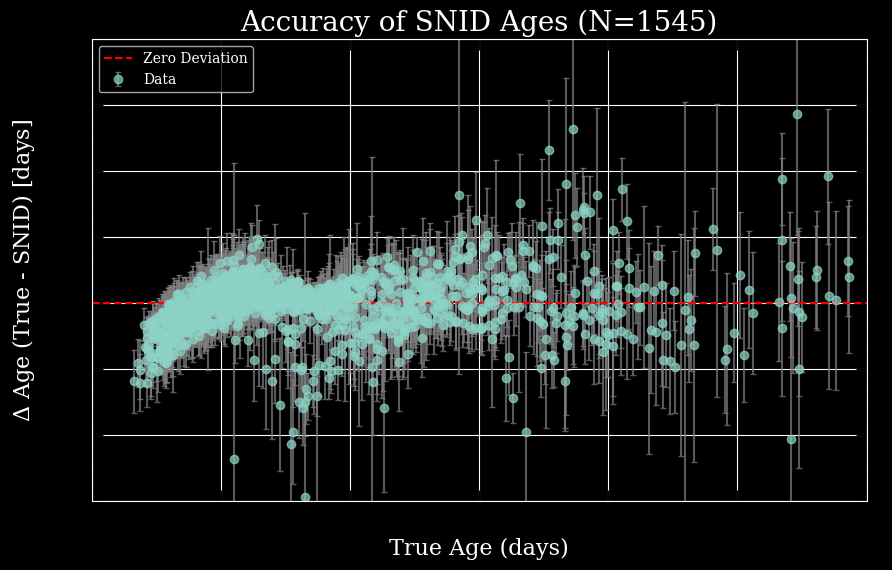

In [26]:
snid_ages_file = 'cfa_supersnid_top20_median/cfa_supersnid_simple_mean_ages.csv'
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_simple_mean.png'
true_age_err_col = 'true_age_err'  # CHANGE THIS to your actual column name for true age uncertainty

# Load Data
snid_ages_df = pd.read_csv(snid_ages_file)
merged_df = pd.merge(spectra_data, snid_ages_df, on='spectrum_filename')

# Force numeric conversion
merged_df['true_age'] = pd.to_numeric(merged_df['true_age'], errors='coerce')
merged_df['mean_age'] = pd.to_numeric(merged_df['mean_age'], errors='coerce')
merged_df['std_dev'] = pd.to_numeric(merged_df['std_dev'], errors='coerce')

# Handle True Age Error: Force numeric and fill NaNs with 0 (Edge case fix)
if true_age_err_col in merged_df.columns:
    merged_df[true_age_err_col] = pd.to_numeric(merged_df[true_age_err_col], errors='coerce').fillna(0)
else:
    print(f"Warning: '{true_age_err_col}' column not found. Assuming 0 uncertainty for True Age.")
    merged_df[true_age_err_col] = 0.0

# Drop rows where essential data (Ages or SNID error) is missing
initial_count = len(merged_df)
merged_df.dropna(subset=['true_age', 'mean_age', 'std_dev'], inplace=True)
final_count = len(merged_df)

print(f"Merged data: {final_count} valid matches found (dropped {initial_count - final_count} rows).")

# Calculate Delta and Propagate Errors (Quadrature sum)
merged_df['delta'] = merged_df['true_age'] - merged_df['mean_age']
merged_df['total_error'] = np.sqrt(merged_df['std_dev']**2 + merged_df[true_age_err_col]**2)

# Plotting
plt.style.use('GausSN.mplstyle')
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x=merged_df['true_age'],
    y=merged_df['delta'],
    yerr=merged_df['total_error'], # Used the propagated error here
    fmt='o',
    alpha=0.7,
    ecolor='gray',
    capsize=2,
    label='Data'
)

# Zero line
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Deviation')

ax.set_xlabel("True Age (days)")
ax.set_ylabel(r"$\Delta$ Age (True - SNID) [days]")
ax.set_title(f"Accuracy of SNID Ages (N={final_count})")
ax.legend()
ax.set_ylim(-30, 40)
ax.set_xlim(-20, 100)

# Save the figure
plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")

plt.show()

In [27]:
print(merged_df.head(10))

                spectrum_filename   sn_name  true_age  true_age_err redshift  \
0    sn1993ac-19931016.49-mmt.flm  sn1993ac      7.29           1.2  0.05030   
1    sn1993ac-19931020.52-mmt.flm  sn1993ac     11.32           1.2  0.05030   
46  sn1994ae-19941129.51-fast.flm  sn1994ae      0.01           0.8  0.00430   
47  sn1994ae-19941130.49-fast.flm  sn1994ae      0.99           0.8  0.00430   
48  sn1994ae-19941201.50-fast.flm  sn1994ae      2.00           0.8  0.00430   
49  sn1994ae-19941202.53-fast.flm  sn1994ae      3.03           0.8  0.00430   
50  sn1994ae-19941202.53-fast.flm  sn1994ae      3.03           0.8  0.00430   
51  sn1994ae-19941203.54-fast.flm  sn1994ae      4.04           0.8  0.00430   
52  sn1994ae-19941204.53-fast.flm  sn1994ae      5.03           0.8  0.00430   
53  sn1994ae-19941207.47-fast.flm  sn1994ae      7.97           0.8  0.00430   

   subtype     snr  mean_age   std_dev   delta  total_error  
0       HV   26.31    4.1600  3.415506  3.1300     3.6201

<h3>
Bootstrap Method

In [28]:
from utils.helper_functions import calculate_bootstrap_median_topn

In [29]:
cfa_supersnid_supersnid_AGES_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/cfa_supersnid_all_spectra_ages.csv'
snid_output_dir = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_extinction_corrected/corrected_spectra'
output_csv_dir = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median'

SNID_RESULTS_FILE = 'cfa_supersnid_top20_median/cfa_supersnid_bootstrap_ages.csv'
OUTPUT_PLOT_FILE = 'cfa_supersnid_top20_median/delta_vs_true_bootstrap.png'

output_files = get_output_files(snid_output_dir)
full_output_path = 'cfa_supersnid_top20_median/cfa_supersnid_bootstrap_ages.csv'
results = []

for f in output_files:
    # Clean up filename for matching/reporting
    spectrum_filename = os.path.basename(f).replace('.output', '').replace('_snid', '.flm').replace('_corrected', '')
    ages, rlaps = parse_snid_file(f)
    std_dev, bootstrap_age = calculate_bootstrap_median_topn(ages, rlaps, top_n=20)

    if bootstrap_age is not None:
        # print(f"  > {spectrum_filename}: Mean Age = {mean_age:.2f}, Std Dev = {std_dev:.2f}")
        results.append({'spectrum_filename': spectrum_filename, 'bootstrap_age': bootstrap_age, 'std_dev': std_dev})
    else:
        print(f"  > Could not calculate mean age for {spectrum_filename} (not enough data).")
        results.append({'spectrum_filename': spectrum_filename, 'bootstrap_age': 'N/A', 'std_dev': 'N/A'})

if results:
    print(f"\n--- Saving results to {full_output_path} ---")

    with open(full_output_path, 'w', newline='') as csvfile:
        fieldnames = ['spectrum_filename', 'bootstrap_age', 'std_dev']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

        writer.writeheader()
        writer.writerows(results)
    print("Done.")


  > Could not calculate mean age for sn2003kf-20050111.11-ldss2.flm (not enough data).
  > Could not calculate mean age for sn2005am-20050517.14-fast.flm (not enough data).
  > Could not calculate mean age for sn2006br-20060427.33-fast.flm (not enough data).
  > Could not calculate mean age for sn1994S-19940612.26-mmt.flm (not enough data).
  > Could not calculate mean age for sn1994ae-19951202.47-mmt.flm (not enough data).
  > Could not calculate mean age for sn1998ab-19980403.38-fast.flm (not enough data).
  > Could not calculate mean age for sn2003hu-20031002.13-fast.flm (not enough data).
  > Could not calculate mean age for sn2003ic-20031017.23-fast.flm (not enough data).
  > Could not calculate mean age for sn2004dt-20041212.18-fast.flm (not enough data).
  > Could not calculate mean age for sn2007ax-20070326.21-fast.flm (not enough data).
  > Could not calculate mean age for sn2002fb-20020929.42-fast.flm (not enough data).
  > Could not calculate mean age for sn1998es-19981114.2

Merged data: 1536 valid matches found (dropped 350 rows).
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_bootstrap_age.png


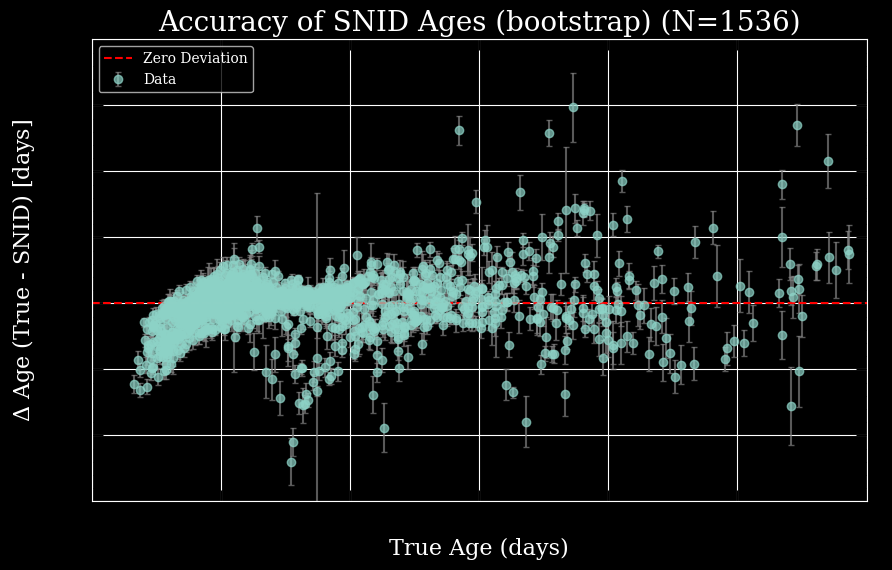

In [30]:
snid_ages_file = 'cfa_supersnid_top20_median/cfa_supersnid_bootstrap_ages.csv'
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_bootstrap_age.png'
true_age_err_col = 'true_age_err'

# Load Data
snid_ages_df = pd.read_csv(snid_ages_file)
merged_df = pd.merge(spectra_data, snid_ages_df, on='spectrum_filename')

# Force numeric conversion
merged_df['true_age'] = pd.to_numeric(merged_df['true_age'], errors='coerce')
merged_df['bootstrap_age'] = pd.to_numeric(merged_df['bootstrap_age'], errors='coerce')
merged_df['std_dev'] = pd.to_numeric(merged_df['std_dev'], errors='coerce')

# Handle True Age Error: Force numeric and fill NaNs with 0 (Edge case fix)
if true_age_err_col in merged_df.columns:
    merged_df[true_age_err_col] = pd.to_numeric(merged_df[true_age_err_col], errors='coerce').fillna(0)
else:
    print(f"Warning: '{true_age_err_col}' column not found. Assuming 0 uncertainty for True Age.")
    merged_df[true_age_err_col] = 0.0

# Drop rows where essential data (Ages or SNID error) is missing
initial_count = len(merged_df)
merged_df.dropna(subset=['true_age', 'bootstrap_age', 'std_dev'], inplace=True)
final_count = len(merged_df)

print(f"Merged data: {final_count} valid matches found (dropped {initial_count - final_count} rows).")

# Calculate Delta and Propagate Errors (Quadrature sum)
merged_df['delta'] = merged_df['true_age'] - merged_df['bootstrap_age']
merged_df['total_error'] = np.sqrt(merged_df['std_dev']**2 + merged_df[true_age_err_col]**2)

# Plotting
plt.style.use('GausSN.mplstyle')
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x=merged_df['true_age'],
    y=merged_df['delta'],
    yerr=merged_df['total_error'], # Used the propagated error here
    fmt='o',
    alpha=0.7,
    ecolor='gray',
    capsize=2,
    label='Data'
)

# Zero line
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Deviation')

ax.set_xlabel("True Age (days)")
ax.set_ylabel(r"$\Delta$ Age (True - SNID) [days]")
ax.set_title(f"Accuracy of SNID Ages (bootstrap) (N={final_count})")
ax.legend()
ax.set_ylim(-30, 40)
ax.set_xlim(-20, 100)

# Save the figure
plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")

plt.show()

In [31]:
sn_names = []
dm15_values = []

# Read the file and parse the names and dm15 values
with open(parameters_file, 'r') as f:
    for line in f:
        # Skip comments and empty lines
        if line.startswith('#') or not line.strip():
            continue

        parts = line.split()

        # Ensure the line has enough columns (Name is col 0, Dm15 is col 5)
        if len(parts) >= 6:
            raw_name = parts[0]

            # --- NAME FORMATTING LOGIC ---
            # 1. If it starts with 'SNF', keep it as is (e.g., SNF20080514-002)
            if raw_name.upper().startswith('SNF'):
                clean_name = raw_name
            # 2. If it doesn't start with 'sn' (e.g., 1993ac), prepend 'sn' -> sn1993ac
            elif not raw_name.lower().startswith('sn'):
                clean_name = 'sn' + raw_name
            # 3. Otherwise (starts with 'sn' but not 'SNF'), keep it
            else:
                clean_name = raw_name
            # -----------------------------

            sn_names.append(clean_name)
            dm15_values.append(parts[5])

# 4. Create a temporary DataFrame for the parameters
dm15_df = pd.DataFrame({
    'sn_name': sn_names,
    'dm15': dm15_values
})

# 5. Clean the dm15 data
# Convert to numeric, turning non-numbers into NaN
dm15_df['dm15'] = pd.to_numeric(dm15_df['dm15'], errors='coerce')

# The file header notes that 9.99 indicates no estimate, so replace it with NaN
dm15_df.loc[dm15_df['dm15'] == 9.99, 'dm15'] = np.nan

# Remove duplicates if the parameter file lists the same SN multiple times
dm15_df = dm15_df.drop_duplicates(subset='sn_name')

# 6. Merge the dm15 column into your existing merged_df
# Check if 'dm15' already exists to avoid duplicate columns
if 'dm15' in merged_df.columns:
    merged_df = merged_df.drop(columns=['dm15'])

# Perform a left join to keep all spectra rows and match dm15 by sn_name
merged_df = pd.merge(merged_df, dm15_df, on='sn_name', how='left')
#
# # 7. Verify the results
# print(f"Merged dm15 values. Rows with valid dm15: {merged_df['dm15'].notna().sum()}")
print(merged_df.head())
print(len(merged_df))

               spectrum_filename   sn_name  true_age  true_age_err redshift  \
0   sn1993ac-19931016.49-mmt.flm  sn1993ac      7.29           1.2  0.05030   
1   sn1993ac-19931020.52-mmt.flm  sn1993ac     11.32           1.2  0.05030   
2  sn1994ae-19941129.51-fast.flm  sn1994ae      0.01           0.8  0.00430   
3  sn1994ae-19941130.49-fast.flm  sn1994ae      0.99           0.8  0.00430   
4  sn1994ae-19941201.50-fast.flm  sn1994ae      2.00           0.8  0.00430   

  subtype     snr  bootstrap_age   std_dev  delta  total_error  dm15  
0      HV   26.31           5.40  1.211776   1.89     1.705404  1.19  
1      HV    5.05          10.00  0.482511   1.32     1.293374  1.19  
2       N  264.78           0.50  1.119887  -0.49     1.376280  0.96  
3       N  279.37           0.95  1.135179   0.04     1.388752  0.96  
4       N  291.35           1.40  1.068212   0.60     1.334570  0.96  
1536


<h3>
Bootstrap Method - Subtypes Removed

Original count: 1536
Plotting 1423 points.


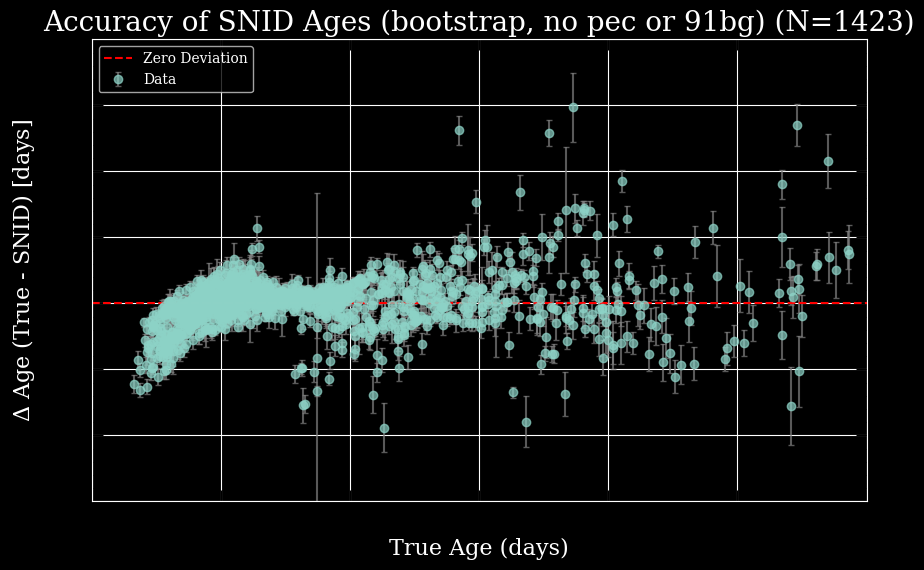

In [32]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_bootstrap_age_subtypes_removed.png'

# 1. Work on a copy of the dataframe
plot_df = merged_df.copy()
print(f"Original count: {len(plot_df)}")


plot_df['subtype'] = plot_df['subtype'].astype(str)
mask_exclude = plot_df['subtype'].str.contains('91bg|N/A|nan', case=False, na=False)
plot_df = plot_df[~mask_exclude]


print(f"Plotting {len(plot_df)} points.")

# 6. Plotting
# plt.style.use('GausSN.mplstyle') # Uncomment if style file exists
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x=plot_df['true_age'],
    y=plot_df['delta'],
    yerr=plot_df['total_error'],
    fmt='o',
    alpha=0.7,
    ecolor='gray',
    capsize=2,
    label='Data'
)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Deviation')

ax.set_xlabel("True Age (days)")
ax.set_ylabel(r"$\Delta$ Age (True - SNID) [days]")
ax.set_title(f"Accuracy of SNID Ages (bootstrap, no pec or 91bg) (N={len(plot_df)})")
ax.legend()
ax.set_ylim(-30, 40)
ax.set_xlim(-20, 100)

plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
plt.show()

<h3>
Bootstrap Method - snr <5 cut

SNR cut (>= 5): Dropped 65 rows. Remaining: 1344
Final count for plotting: 1344
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_bootstrap_age_subtypes_removed_snr_cut.png


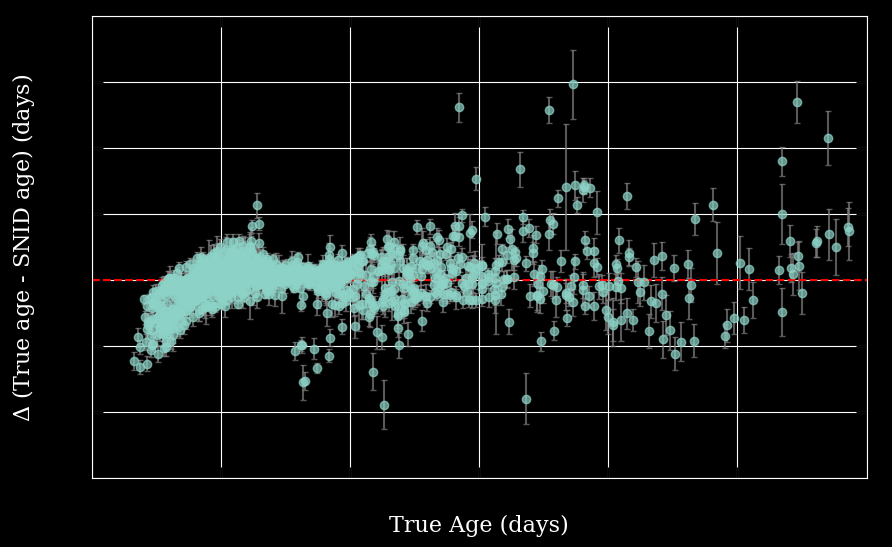

In [78]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/delta_vs_true_bootstrap_age_subtypes_removed_snr_cut.png'

snr91_cut_df = merged_df.copy()

# 2. Filter Subtypes (Remove '91bg', 'N/A', 'nan')
snr91_cut_df['subtype'] = snr91_cut_df['subtype'].astype(str)
mask_exclude = snr91_cut_df['subtype'].str.contains('91bg|N/A|nan', case=False, na=False)
snr91_cut_df = snr91_cut_df[~mask_exclude]

# 3. Apply SNR Cut
# Ensure SNR is numeric before filtering
snr91_cut_df['snr'] = pd.to_numeric(snr91_cut_df['snr'], errors='coerce')

count_before_snr = len(snr91_cut_df)
snr91_cut_df = snr91_cut_df[snr91_cut_df['snr'] >= 10]
count_after_snr = len(snr91_cut_df)

print(f"SNR cut (>= 5): Dropped {count_before_snr - count_after_snr} rows. Remaining: {count_after_snr}")

snr91_cut_df.dropna(subset=['delta', 'true_age', 'total_error'], inplace=True)
final_count = len(snr91_cut_df)
print(f"Final count for plotting: {final_count}")

# 5. Plotting
plt.style.use('GausSN.mplstyle')
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x=snr91_cut_df['true_age'],
    y=snr91_cut_df['delta'],          # Using existing column
    yerr=snr91_cut_df['total_error'], # Using existing column
    fmt='o',
    alpha=0.7,
    ecolor='gray',
    capsize=2,
    label='Data'
)

# Zero line
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Deviation')

ax.set_xlabel("True Age (days)")
ax.set_ylabel(r"$\Delta$ (True age - SNID age) (days)")
# ax.set_title(f"Accuracy of SNID Ages (bootstrap) (N={final_count})")
# ax.legend()
ax.set_ylim(-30, 40)
ax.set_xlim(-20, 100)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE, dpi=500, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")

plt.show()

In [79]:
# cutting wrt snr with snr > 5 kept

merged_df['snr'] = pd.to_numeric(merged_df['snr'], errors='coerce')

count_before_snr = len(merged_df)
merged_df = merged_df[merged_df['snr'] >= 10]
count_after_snr = len(merged_df)

print(f"SNR cut (>= 10): Dropped {count_before_snr - count_after_snr} rows. Remaining: {count_after_snr}")

merged_df.to_csv('/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/bootstrap_top_20_median_results.csv', index=False)



SNR cut (>= 10): Dropped 73 rows. Remaining: 1447


<h3>
SNID Age Error vs. True Age

Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age.png


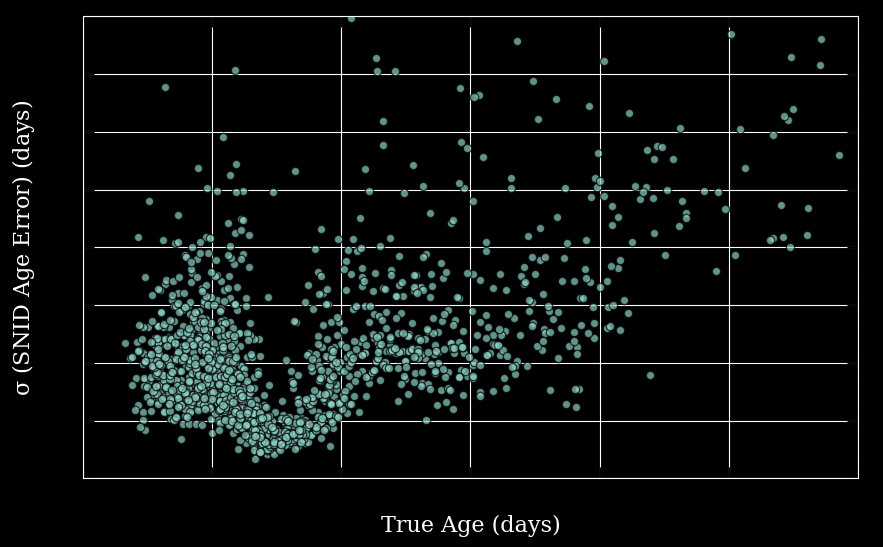

In [35]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age.png'
fig, ax = plt.subplots(figsize=(10, 6))

df_to_plot = snr91_cut_df.copy()

# Scatter plot
scatter = ax.scatter(
    df_to_plot['true_age'],
    df_to_plot['std_dev'],
    alpha=0.7,
    edgecolors='k'
)
final_count = len(df_to_plot)
ax.set_xlabel("True Age (days)")
ax.set_ylabel(r"$\sigma$ (SNID Age Error) (days)")
# Title with N count as subtitle (using newline method)
# ax.set_title(f"SNID Age Error vs. True Age\n(N={final_count})")

# ax.legend()
ax.set_xlim(-20, 100)
ax.set_ylim(0, 4)

# Save the figure
plt.savefig(OUTPUT_PLOT_FILE, dpi=500, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")

plt.show()

# print(merged_df.head())

<h3>
SNID error v Dm15

Plotting 1429 points.
(Dropped 91 rows due to missing dm15 or std_dev values)
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_dm15.png


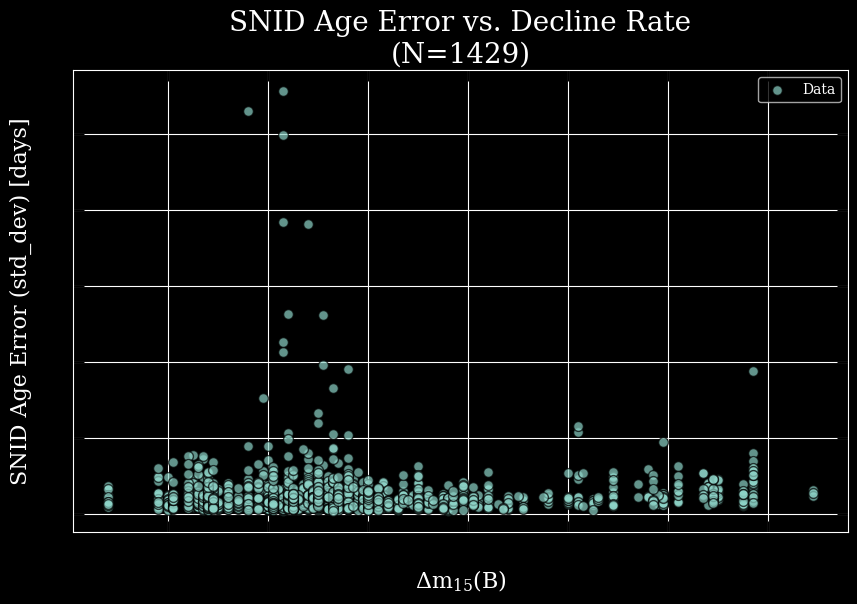

In [36]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_dm15.png'

df_to_plot = merged_df.copy()


plot_df = df_to_plot.dropna(subset=['std_dev', 'dm15'])

final_count = len(plot_df)
original_count = len(df_to_plot)
dropped_count = original_count - final_count

print(f"Plotting {final_count} points.")
print(f"(Dropped {dropped_count} rows due to missing dm15 or std_dev values)")

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    plot_df['dm15'],
    plot_df['std_dev'],
    alpha=0.7,
    edgecolors='k',
    s=50, # Marker size
    label='Data'
)

# Labels and Title
ax.set_xlabel(r"$\Delta m_{15}(B)$") # LaTeX formatting for dm15
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. Decline Rate\n(N={final_count})")

ax.legend()

# Optional: Set limits if you want to zoom in
# ax.set_ylim(0, 5)
# ax.set_xlim(0.5, 2.0)

# Save the figure
plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")

plt.show()

Plotting 1429 points.
(Dropped 91 rows due to missing dm15 or delta values)
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_dm15.png


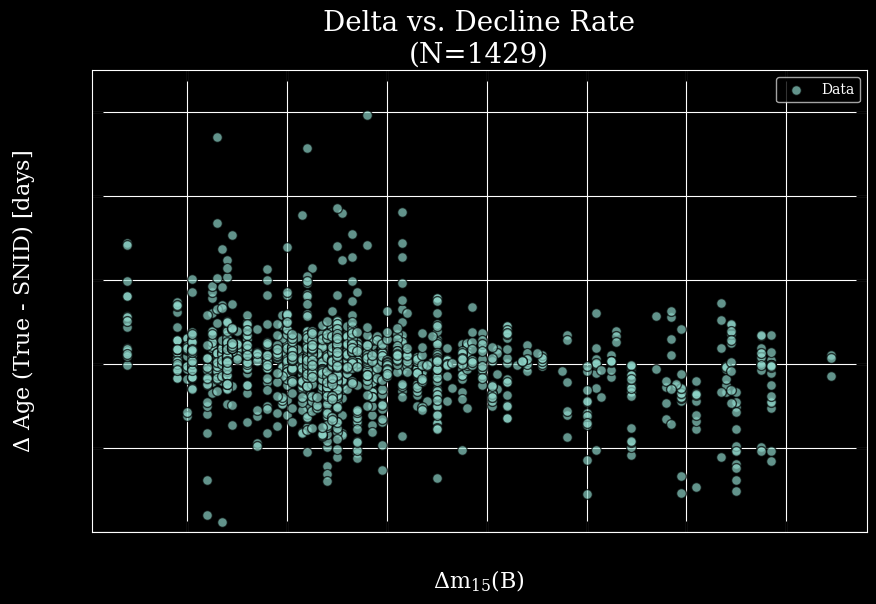

In [37]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_dm15.png'

df_to_plot = merged_df.copy()
plot_df = df_to_plot.dropna(subset=['delta', 'dm15'])

final_count = len(plot_df)
original_count = len(df_to_plot)
dropped_count = original_count - final_count

print(f"Plotting {final_count} points.")
print(f"(Dropped {dropped_count} rows due to missing dm15 or delta values)")

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    plot_df['dm15'],
    plot_df['delta'],
    alpha=0.7,
    edgecolors='k',
    s=50, # Marker size
    label='Data'
)

# Labels and Title
ax.set_xlabel(r"$\Delta m_{15}(B)$") # LaTeX formatting for dm15
ax.set_ylabel(r"$\Delta$ Age (True - SNID) [days]")
ax.set_title(f"Delta vs. Decline Rate\n(N={final_count})")

ax.legend()

# Optional: Set limits if you want to zoom in
ax.set_ylim(-20, 35)
# ax.set_xlim(0.5, 2.0)

# Save the figure
plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")

plt.show()

In [38]:
print(merged_df.head())
print(merged_df['snr'].min())
print(merged_df['subtype'].unique())

               spectrum_filename   sn_name  true_age  true_age_err redshift  \
0   sn1993ac-19931016.49-mmt.flm  sn1993ac      7.29           1.2  0.05030   
1   sn1993ac-19931020.52-mmt.flm  sn1993ac     11.32           1.2  0.05030   
2  sn1994ae-19941129.51-fast.flm  sn1994ae      0.01           0.8  0.00430   
3  sn1994ae-19941130.49-fast.flm  sn1994ae      0.99           0.8  0.00430   
4  sn1994ae-19941201.50-fast.flm  sn1994ae      2.00           0.8  0.00430   

  subtype     snr  bootstrap_age   std_dev  delta  total_error  dm15  
0      HV   26.31           5.40  1.211776   1.89     1.705404  1.19  
1      HV    5.05          10.00  0.482511   1.32     1.293374  1.19  
2       N  264.78           0.50  1.119887  -0.49     1.376280  0.96  
3       N  279.37           0.95  1.135179   0.04     1.388752  0.96  
4       N  291.35           1.40  1.068212   0.60     1.334570  0.96  
5.05
[np.str_('HV') np.str_('N') np.str_('N/A') np.str_('91bg') np.str_('91T')]


<h1>
SNID age error v. True age

<h3>
91bg

Final count for plotting (91bg only): 87
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_91bg_only.png


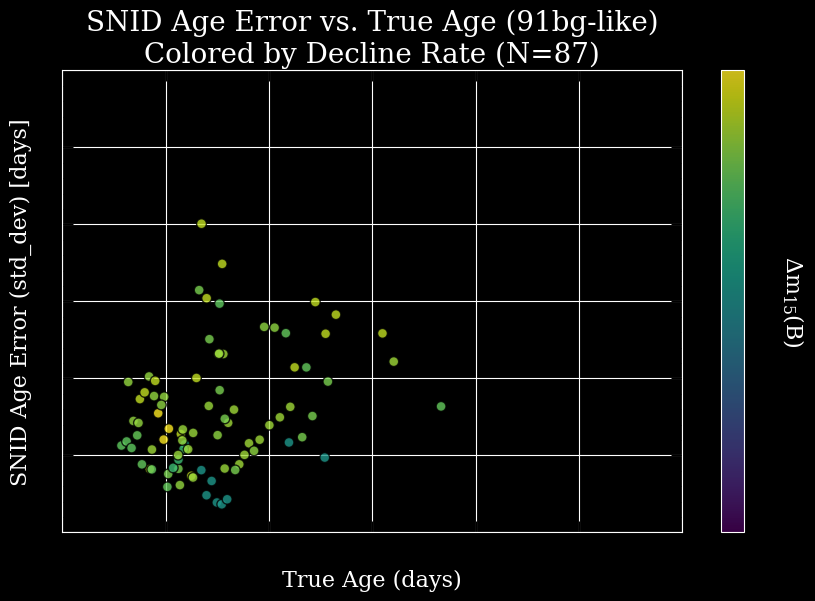

In [39]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_91bg_only.png'

plot_df = merged_df.copy()

# Filter for subtype '91bg' (case-insensitive)
if 'subtype' in plot_df.columns:
    plot_df = plot_df[plot_df['subtype'].astype(str).str.contains('91bg', case=False, na=False)]
else:
    print("Warning: 'subtype' column missing. No filtering applied.")

plot_df = plot_df.dropna(subset=['true_age', 'std_dev', 'dm15'])

print(f"Final count for plotting (91bg only): {len(plot_df)}")

# PLOTTING

plt.style.use('GausSN.mplstyle')

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['true_age'],
    plot_df['std_dev'],
    c=plot_df['dm15'],
    cmap='viridis',
    vmin=0.7, vmax=2.1,
    alpha=0.8,
    edgecolors='k',
    s=50,
    label='91bg-like'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\Delta m_{15}(B)$", rotation=270, labelpad=15)

ax.set_xlabel("True Age (days)")
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. True Age (91bg-like)\nColored by Decline Rate (N={len(plot_df)})")

ax.set_xlim(-20, 100)
ax.set_ylim(0, 6)

plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")
plt.show()

# print("\nCheck dm15 < 1.8:")
# print(plot_df[plot_df['dm15'] < 1.8][['sn_name', 'true_age', 'std_dev', 'dm15']].head())

<h3>
HV

Final count for plotting (HV only): 304
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_HV_only.png


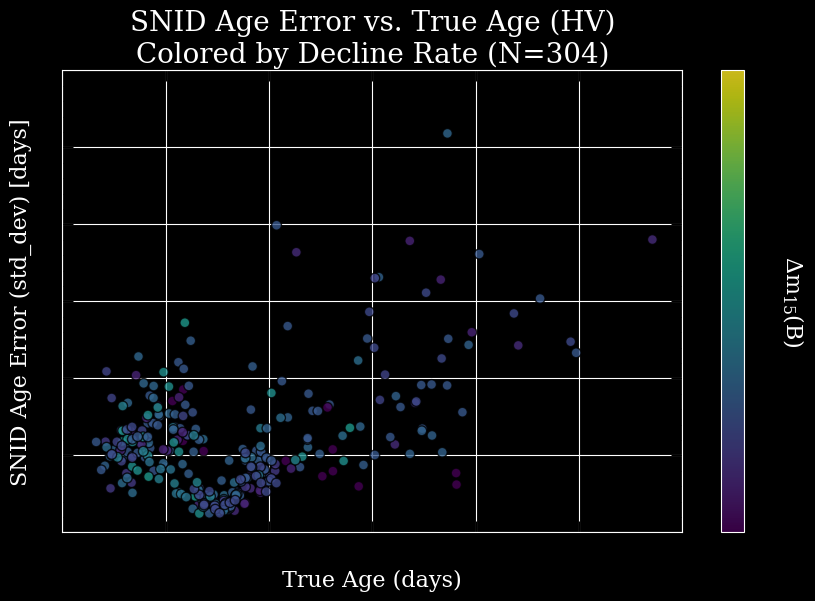

In [40]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_HV_only.png'
plot_df = merged_df.copy()

# Filter for subtype 'HV' (case-insensitive)
if 'subtype' in plot_df.columns:
    plot_df = plot_df[plot_df['subtype'].astype(str).str.contains('HV', case=False, na=False)]
else:
    print("Warning: 'subtype' column missing. No filtering applied.")

plot_df = plot_df.dropna(subset=['true_age', 'std_dev', 'dm15'])

print(f"Final count for plotting (HV only): {len(plot_df)}")

# PLOTTING

plt.style.use('GausSN.mplstyle')

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['true_age'],
    plot_df['std_dev'],
    c=plot_df['dm15'],
    cmap='viridis',
    vmin=0.7, vmax=2.1,
    alpha=0.8,
    edgecolors='k',
    s=50,
    label='HV'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\Delta m_{15}(B)$", rotation=270, labelpad=15)

ax.set_xlabel("True Age (days)")
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. True Age (HV)\nColored by Decline Rate (N={len(plot_df)})")

ax.set_xlim(-20, 100)
ax.set_ylim(0, 6)

plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")
plt.show()

<h3>
91T

Final count for plotting (91T only): 174
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_91T_only.png


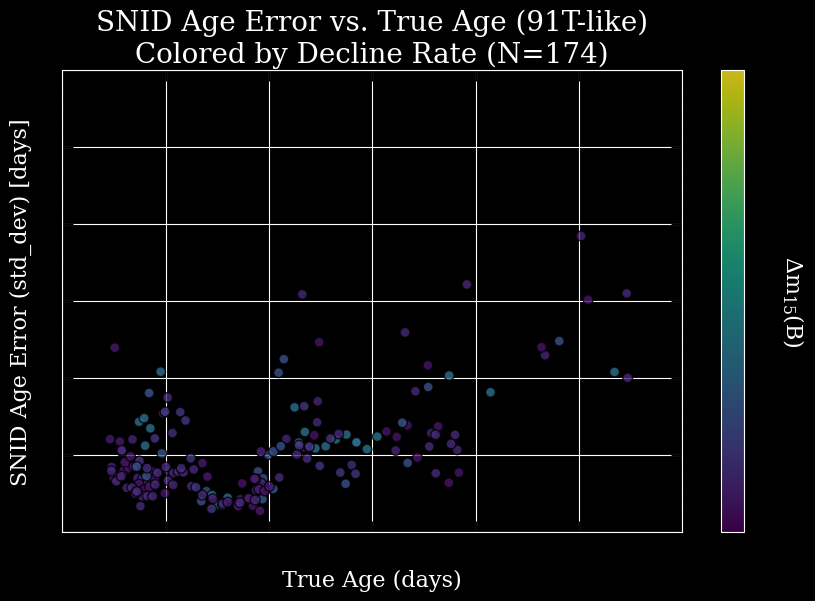

In [41]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_91T_only.png'
plot_df = merged_df.copy()

# Filter for subtype '91T' (case-insensitive)
if 'subtype' in plot_df.columns:
    plot_df = plot_df[plot_df['subtype'].astype(str).str.contains('91T', case=False, na=False)]
else:
    print("Warning: 'subtype' column missing. No filtering applied.")

plot_df = plot_df.dropna(subset=['true_age', 'std_dev', 'dm15'])

print(f"Final count for plotting (91T only): {len(plot_df)}")

# PLOTTING

plt.style.use('GausSN.mplstyle')

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['true_age'],
    plot_df['std_dev'],
    c=plot_df['dm15'],
    cmap='viridis',
    vmin=0.7, vmax=2.1,
    alpha=0.8,
    edgecolors='k',
    s=50,
    label='91T-like'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\Delta m_{15}(B)$", rotation=270, labelpad=15)

ax.set_xlabel("True Age (days)")
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. True Age (91T-like)\nColored by Decline Rate (N={len(plot_df)})")

ax.set_xlim(-20, 100)
ax.set_ylim(0, 6)

plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")
plt.show()

<h3>
N

Final count for plotting (N only): 864
Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_N_only.png


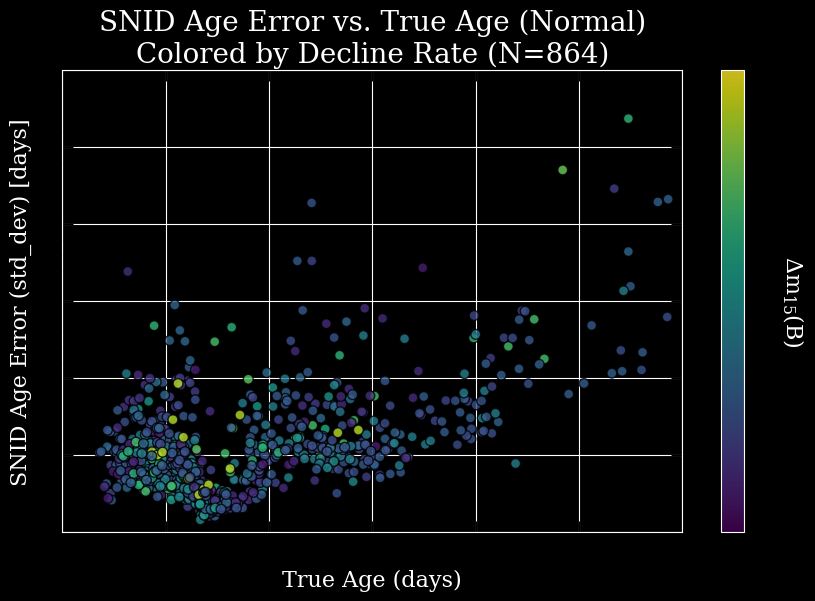

In [42]:
OUTPUT_PLOT_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_colored_dm15_N_only.png'
plot_df = merged_df.copy()

# Filter for subtype 'N' (case-insensitive)
if 'subtype' in plot_df.columns:
    plot_df = plot_df[plot_df['subtype'].astype(str).str.contains('N', case=False, na=False)]
else:
    print("Warning: 'subtype' column missing. No filtering applied.")

plot_df = plot_df.dropna(subset=['true_age', 'std_dev', 'dm15'])

print(f"Final count for plotting (N only): {len(plot_df)}")

# PLOTTING

plt.style.use('GausSN.mplstyle')

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    plot_df['true_age'],
    plot_df['std_dev'],
    c=plot_df['dm15'],
    cmap='viridis',
    vmin=0.7, vmax=2.1,
    alpha=0.8,
    edgecolors='k',
    s=50,
    label='Normal'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\Delta m_{15}(B)$", rotation=270, labelpad=15)

ax.set_xlabel("True Age (days)")
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. True Age (Normal)\nColored by Decline Rate (N={len(plot_df)})")

ax.set_xlim(-20, 100)
ax.set_ylim(0, 6)

plt.savefig(OUTPUT_PLOT_FILE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE}")
plt.show()


Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_delta_magnitude_cut.png


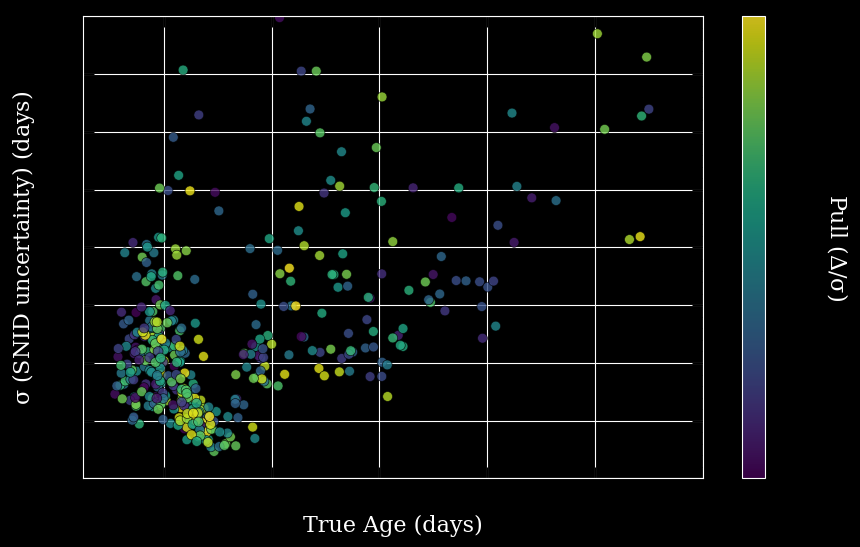

In [43]:
OUTPUT_PLOT_FILE_MAG = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_supersnid_top20_median/snid_error_vs_true_age_delta_magnitude_cut.png'

plot_mag_df = merged_df.copy()

# 4. Drop NaNs
plot_mag_df.dropna(subset=['true_age', 'bootstrap_age', 'std_dev', 'delta'], inplace=True)

# 5. Apply The Filter: |Delta| <= Sigma (std_dev)
# (Using the existing 'delta' column from merged_df)
plot_mag_df = plot_mag_df[np.abs(plot_mag_df['delta']) <= plot_mag_df['std_dev']]
final_count_mag = len(plot_mag_df)


# 6. Calculate Pull for Coloring
plot_mag_df['pull_val'] = plot_mag_df['delta'] / plot_mag_df['std_dev']

# 7. Plotting
plt.style.use('GausSN.mplstyle')
fig_mag, ax_mag = plt.subplots(figsize=(10, 6))

sc_mag = ax_mag.scatter(
    plot_mag_df['true_age'],
    plot_mag_df['std_dev'],
    c=plot_mag_df['pull_val'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='k',
    linewidth=0.5,
    s=50,
    label='All Subtypes'
)

# Add Colorbar
cbar_mag = plt.colorbar(sc_mag, ax=ax_mag)
cbar_mag.set_label(r"Pull ($\Delta / \sigma$)", rotation=270, labelpad=15)

# Labels and Title
ax_mag.set_xlabel("True Age (days)")
ax_mag.set_ylabel(r"$\sigma$ (SNID uncertainty) (days)")

# Title string
# title_str = "SNID Error v. True Age\nFiltered: " + r"$|\Delta| \leq \sigma$" + f" (N={final_count_mag})"
# ax_mag.set_title(title_str)

# Limits
ax_mag.set_xlim(-15, 100)
ax_mag.set_ylim(0, 4.0)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_MAG, dpi=500, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE_MAG}")

plt.show()

In [44]:
print(plot_mag_df.head(10))

                spectrum_filename   sn_name  true_age  true_age_err redshift  \
2   sn1994ae-19941129.51-fast.flm  sn1994ae      0.01           0.8  0.00430   
3   sn1994ae-19941130.49-fast.flm  sn1994ae      0.99           0.8  0.00430   
4   sn1994ae-19941201.50-fast.flm  sn1994ae      2.00           0.8  0.00430   
5   sn1994ae-19941202.53-fast.flm  sn1994ae      3.03           0.8  0.00430   
6   sn1994ae-19941202.53-fast.flm  sn1994ae      3.03           0.8  0.00430   
11  sn1994ae-19941208.55-fast.flm  sn1994ae      9.05           0.8  0.00430   
19  sn1994ae-19950501.20-fast.flm  sn1994ae    152.70           0.8  0.00430   
20  sn1995al-19951114.52-fast.flm  sn1995al      6.42           0.6  0.00510   
23  sn1995al-19951121.45-fast.flm  sn1995al     13.35           0.6  0.00510   
30  sn1995al-19951222.47-fast.flm  sn1995al     44.37           0.6  0.00510   

   subtype     snr  bootstrap_age    std_dev  delta  total_error  dm15  \
2        N  264.78           0.50   1.119887 

In [45]:
# ==========================================
# PRINT SPECTRA
# ==========================================

# ---------------------------------------------------------
# 1. Search near 0 Days (Logic: Within True Age Error)
# ---------------------------------------------------------
print("\n" + "="*60)
print(" SPECTRA CONSISTENT WITH 0 DAYS (Within individual True Age Error)")
print("="*60)

# Logic: |true_age - 0| <= true_age_err
at_zero = plot_mag_df[
    np.abs(plot_mag_df['true_age'] - 0.0) <= plot_mag_df['true_age_err']
]

if not at_zero.empty:
    cols = ['spectrum_filename', 'sn_name', 'true_age', 'true_age_err', 'delta']
    print(at_zero[cols].to_string(index=False))
    print(f"\nTotal found: {len(at_zero)}")
else:
    print("No spectra found where 0 days lies within the true age error.")


# ---------------------------------------------------------
# 2. Search near 10 Days (Logic: Fixed Window +/- 1 Day)
# ---------------------------------------------------------
print("\n" + "="*60)
print(" SPECTRA NEAR 10 DAYS (Window: 9.0 to 11.0 days)")
print("="*60)

# Logic: 9.0 <= true_age <= 11.0
at_ten = plot_mag_df[
    (plot_mag_df['true_age'] >= 9.0) &
    (plot_mag_df['true_age'] <= 11.0)
]

if not at_ten.empty:
    cols = ['spectrum_filename', 'sn_name', 'true_age', 'true_age_err', 'delta']
    print(at_ten[cols].to_string(index=False))
    print(f"\nTotal found: {len(at_ten)}")
else:
    print("No spectra found between 9.0 and 11.0 days.")


 SPECTRA CONSISTENT WITH 0 DAYS (Within individual True Age Error)
            spectrum_filename  sn_name  true_age  true_age_err  delta
sn1994ae-19941129.51-fast.flm sn1994ae      0.01           0.8  -0.49
sn1998aq-19980428.26-fast.flm sn1998aq      0.06           0.4   0.81
sn1998dh-19980804.36-fast.flm sn1998dh     -0.54           0.9   0.06
sn1999aa-19990223.25-fast.flm sn1999aa     -0.15           0.9  -0.20
sn1999cc-19990517.40-fast.flm sn1999cc     -0.20           0.3  -0.60
sn1999dq-19990915.45-fast.flm sn1999dq      0.45           0.7   0.50
sn2000dg-20000902.38-fast.flm sn2000dg     -0.82           1.3  -0.92
sn2001br-20010521.44-fast.flm sn2001br     -0.46           0.8   0.79
sn2002ck-20020502.46-fast.flm sn2002ck     -0.54           0.6   0.36
sn2002ck-20020503.34-fast.flm sn2002ck      0.34           0.6  -0.16
sn2003cg-20030331.21-fast.flm sn2003cg     -0.19           0.4  -0.49
sn2003cq-20030409.25-fast.flm sn2003cq      0.05           0.9   0.25
sn2003kc-20031203.49-f

Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_true_age_delta_magnitude_cut_redshift.png


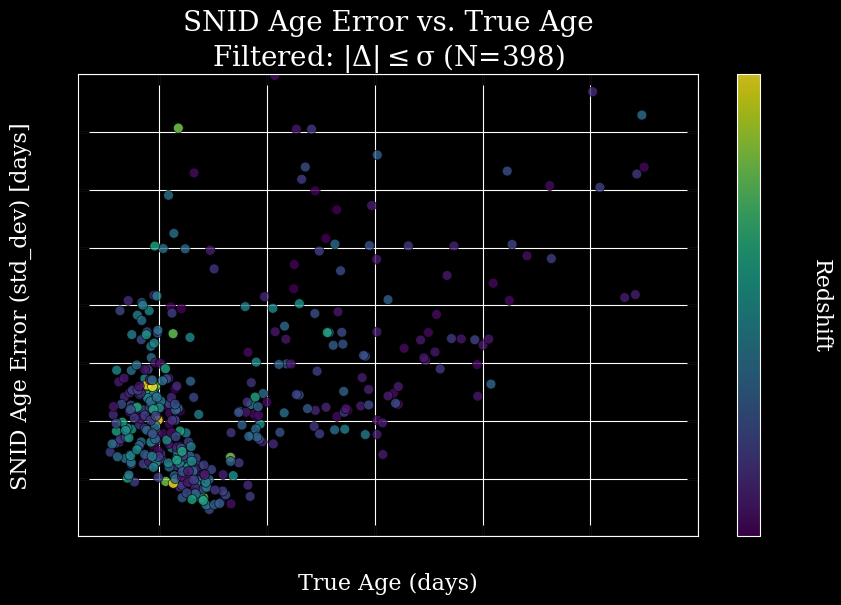

In [46]:
OUTPUT_PLOT_FILE_MAG = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_true_age_delta_magnitude_cut_redshift.png'

# 1. Create a working copy
plot_mag_df = merged_df.copy()

# 2. Ensure Redshift is numeric (and other key columns)
# Assuming the column is named 'redshift'. If it is 'z', change the string below.
col_redshift = 'redshift'
plot_mag_df[col_redshift] = pd.to_numeric(plot_mag_df[col_redshift], errors='coerce')

# 3. Drop NaNs
# We now include redshift in the subset to ensure we can color every point
plot_mag_df.dropna(subset=['true_age', 'bootstrap_age', 'std_dev', 'delta', col_redshift], inplace=True)

# 4. Apply The Filter: |Delta| <= Sigma (std_dev)
plot_mag_df = plot_mag_df[np.abs(plot_mag_df['delta']) <= plot_mag_df['std_dev']]
final_count_mag = len(plot_mag_df)

# 5. Plotting
plt.style.use('GausSN.mplstyle')
fig_mag, ax_mag = plt.subplots(figsize=(10, 6))

sc_mag = ax_mag.scatter(
    plot_mag_df['true_age'],
    plot_mag_df['std_dev'],
    c=plot_mag_df[col_redshift], # <--- Changed to Redshift
    cmap='viridis',              # Viridis is great for sequential data like redshift
    alpha=0.8,
    edgecolors='k',
    linewidth=0.5,
    s=50,
    label='All Subtypes'
)

# Add Colorbar
cbar_mag = plt.colorbar(sc_mag, ax=ax_mag)
cbar_mag.set_label("Redshift", rotation=270, labelpad=15) # <--- Updated Label

# Labels and Title
ax_mag.set_xlabel("True Age (days)")
ax_mag.set_ylabel("SNID Age Error (std_dev) [days]")

# Title string
title_str = "SNID Age Error vs. True Age\nFiltered: " + r"$|\Delta| \leq \sigma$" + f" (N={final_count_mag})"
ax_mag.set_title(title_str)

# Limits
ax_mag.set_xlim(-15, 100)
ax_mag.set_ylim(0, 4.0)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_MAG, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE_MAG}")

plt.show()

Plotting 1520 points after filtering.
Plot saved to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_redshift_plain.png


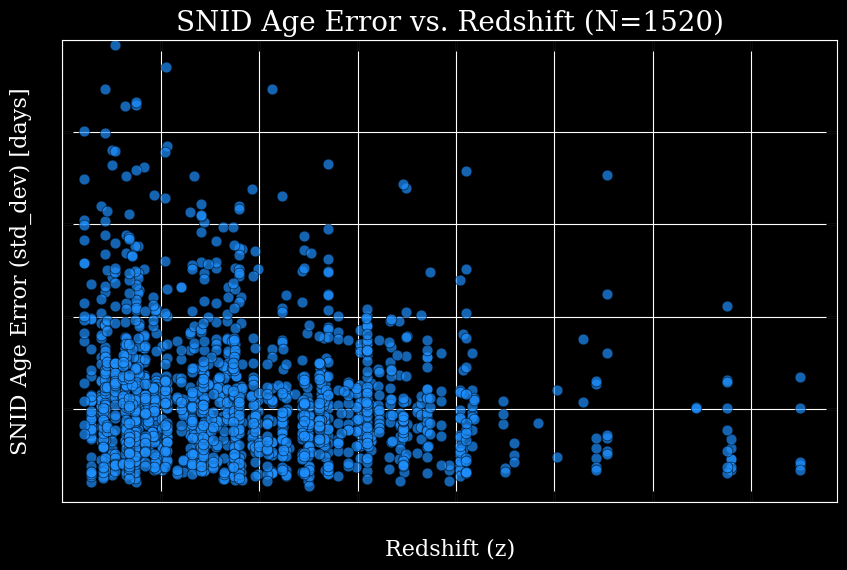

In [47]:
OUTPUT_PLOT_FILE_Z = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_redshift_plain.png'

# 1. Prepare Data
plot_z_df = merged_df.copy()

# 2. Ensure Numeric Columns
z_col = 'redshift' # Check if this matches your dataframe column name
cols_to_check = ['std_dev', z_col, 'snr']
for c in cols_to_check:
    plot_z_df[c] = pd.to_numeric(plot_z_df[c], errors='coerce')

# 3. Apply Quality Cuts (SNR >= 5)
plot_z_df = plot_z_df[plot_z_df['snr'] >= 5]

# 4. Drop Missing Data
plot_z_df.dropna(subset=['std_dev', z_col], inplace=True)

print(f"Plotting {len(plot_z_df)} points after filtering.")

# 5. Plotting
plt.style.use('GausSN.mplstyle')
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter Plot (Single color)
ax.scatter(
    plot_z_df[z_col],
    plot_z_df['std_dev'],
    c='dodgerblue',    # Solid color since we removed the colorbar dimension
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=60,
    label='Data'
)

# Labels and Title
ax.set_xlabel("Redshift (z)")
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. Redshift (N={len(plot_z_df)})")

# Limits
ax.set_xlim(0, plot_z_df[z_col].max() * 1.05)
ax.set_ylim(0, 5)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_Z, dpi=300, bbox_inches='tight')
print(f"Plot saved to {OUTPUT_PLOT_FILE_Z}")

plt.show()

Plotting 1520 points after filtering.
Plot saved to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/true_age_vs_redshift.png


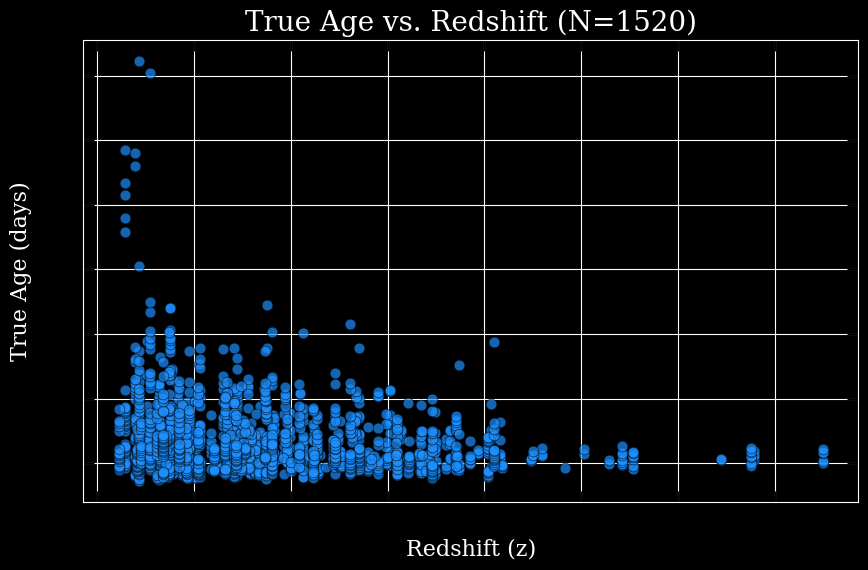

In [48]:
OUTPUT_PLOT_FILE_AGE_Z = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/true_age_vs_redshift.png'

# 1. Prepare Data
plot_age_z_df = merged_df.copy()

# 2. Ensure Numeric Columns
# Check for 'redshift' or 'zhel'
if 'redshift' in plot_age_z_df.columns:
    z_col = 'redshift'
elif 'zhel' in plot_age_z_df.columns:
    z_col = 'zhel'
else:
    raise ValueError("Could not find 'redshift' or 'zhel' column in dataframe.")

cols_to_check = ['true_age', z_col, 'snr']
for c in cols_to_check:
    plot_age_z_df[c] = pd.to_numeric(plot_age_z_df[c], errors='coerce')

# 3. Apply Quality Cuts (SNR >= 5)
plot_age_z_df = plot_age_z_df[plot_age_z_df['snr'] >= 5]

# 4. Drop Missing Data
plot_age_z_df.dropna(subset=['true_age', z_col], inplace=True)

print(f"Plotting {len(plot_age_z_df)} points after filtering.")

# 5. Plotting
plt.style.use('GausSN.mplstyle')
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter Plot (Swapped X and Y)
ax.scatter(
    plot_age_z_df[z_col],      # X-axis: Redshift
    plot_age_z_df['true_age'], # Y-axis: True Age
    c='dodgerblue',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=60,
    label='Data'
)

# Labels and Title
ax.set_xlabel("Redshift (z)")
ax.set_ylabel("True Age (days)")
ax.set_title(f"True Age vs. Redshift (N={len(plot_age_z_df)})")

# Optional: Limits
# ax.set_xlim(0, 0.1)
# ax.set_ylim(-20, 100)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_AGE_Z, dpi=300, bbox_inches='tight')
print(f"Plot saved to {OUTPUT_PLOT_FILE_AGE_Z}")

plt.show()

In [49]:
plot_snr_df = merged_df.copy()
print(plot_snr_df)

                  spectrum_filename   sn_name  true_age  true_age_err  \
0      sn1993ac-19931016.49-mmt.flm  sn1993ac      7.29           1.2   
1      sn1993ac-19931020.52-mmt.flm  sn1993ac     11.32           1.2   
2     sn1994ae-19941129.51-fast.flm  sn1994ae      0.01           0.8   
3     sn1994ae-19941130.49-fast.flm  sn1994ae      0.99           0.8   
4     sn1994ae-19941201.50-fast.flm  sn1994ae      2.00           0.8   
...                             ...       ...       ...           ...   
1531  sn2008bf-20080501.22-fast.flm  sn2008bf     32.62           0.4   
1532  sn2008bf-20080508.31-fast.flm  sn2008bf     39.71           0.4   
1533  sn2008bf-20080511.20-fast.flm  sn2008bf     42.60           0.4   
1534  sn2008bf-20080530.16-fast.flm  sn2008bf     61.56           0.4   
1535  sn2008bf-20080607.19-fast.flm  sn2008bf     69.59           0.4   

     redshift subtype     snr  bootstrap_age   std_dev  delta  total_error  \
0     0.05030      HV   26.31           5.40 

Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_snr.png


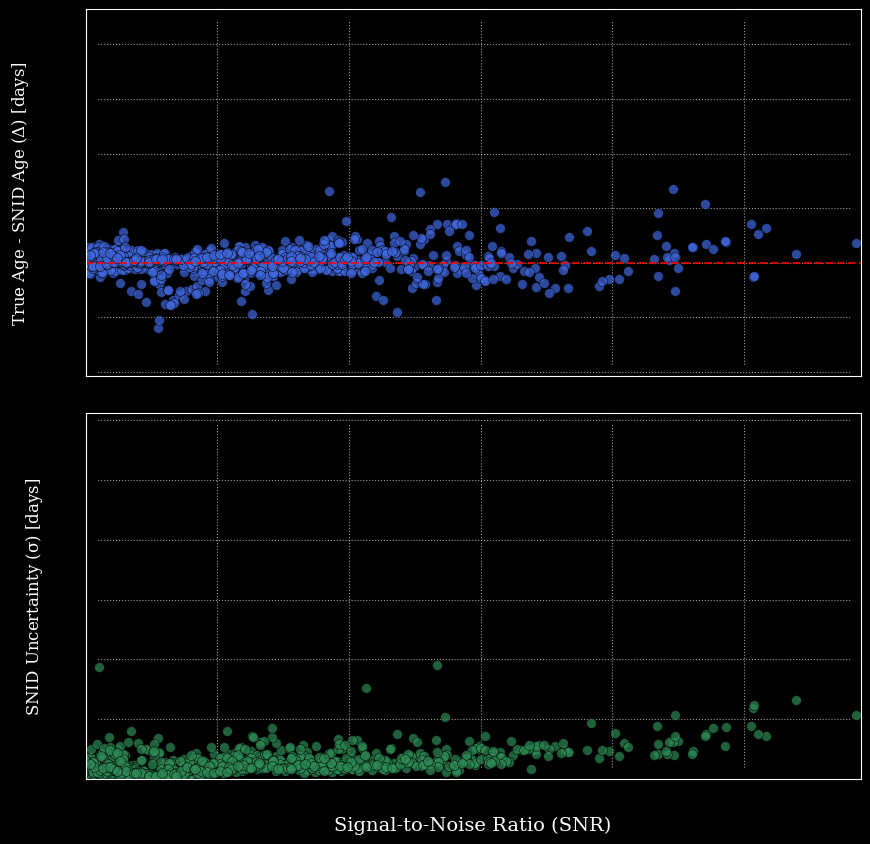

In [50]:
OUTPUT_PLOT_FILE_SNR = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_snr.png'

# 1. Prepare Data
# Use merged_df to see the full distribution, including outliers at low SNR
plot_snr_df = merged_df.copy()
plot_snr_df.dropna(subset=['snr', 'delta', 'std_dev'], inplace=True)

# Optional: Cut off extremely high SNR outliers for better plotting if needed
# plot_snr_df = plot_snr_df[plot_snr_df['snr'] < 100]

# 2. Setup Plot
try:
    plt.style.use('GausSN.mplstyle')
except OSError:
    print("Style not found, using default.")

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
plt.subplots_adjust(hspace=0.1) # Reduce gap between plots

# -----------------------------
# Panel 1: Accuracy (Delta vs SNR)
# -----------------------------
axes[0].scatter(
    plot_snr_df['true_age'],
    plot_snr_df['delta'],
    c='royalblue',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=50,
    label='Residuals'
)

axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel(r"True Age - SNID Age ($\Delta$) [days]", fontsize=12)
# axes[0].set_title("Accuracy: Age Mismatch vs. Signal Quality", fontsize=14)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Add standard deviation bounds as a guide?
# axes[0].axhline(2, color='gray', linestyle=':', alpha=0.5)
# axes[0].axhline(-2, color='gray', linestyle=':', alpha=0.5)


# -----------------------------
# Panel 2: Precision (Sigma vs SNR)
# -----------------------------
axes[1].scatter(
    plot_snr_df['true_age'],
    plot_snr_df['std_dev'],
    c='seagreen',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=50,
    label='Uncertainty'
)

axes[1].set_ylabel(r"SNID Uncertainty ($\sigma$) [days]", fontsize=12)
axes[1].set_xlabel("Signal-to-Noise Ratio (SNR)", fontsize=14)
# axes[1].set_title("Precision: Model Confidence vs. Signal Quality", fontsize=14)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Set logical limits
# Assuming SNR goes from 0 to ~50 or 100
max_snr = np.percentile(plot_snr_df['true_age'], 99) * 1.1 # 99th percentile to ignore extreme outliers
axes[1].set_xlim(0, max_snr)
# axes[1].set_xlim(0, 10)

axes[1].set_ylim(0, np.max(plot_snr_df['std_dev']) * 1.1)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_SNR, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE_SNR}")

plt.show()

Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_snr.png


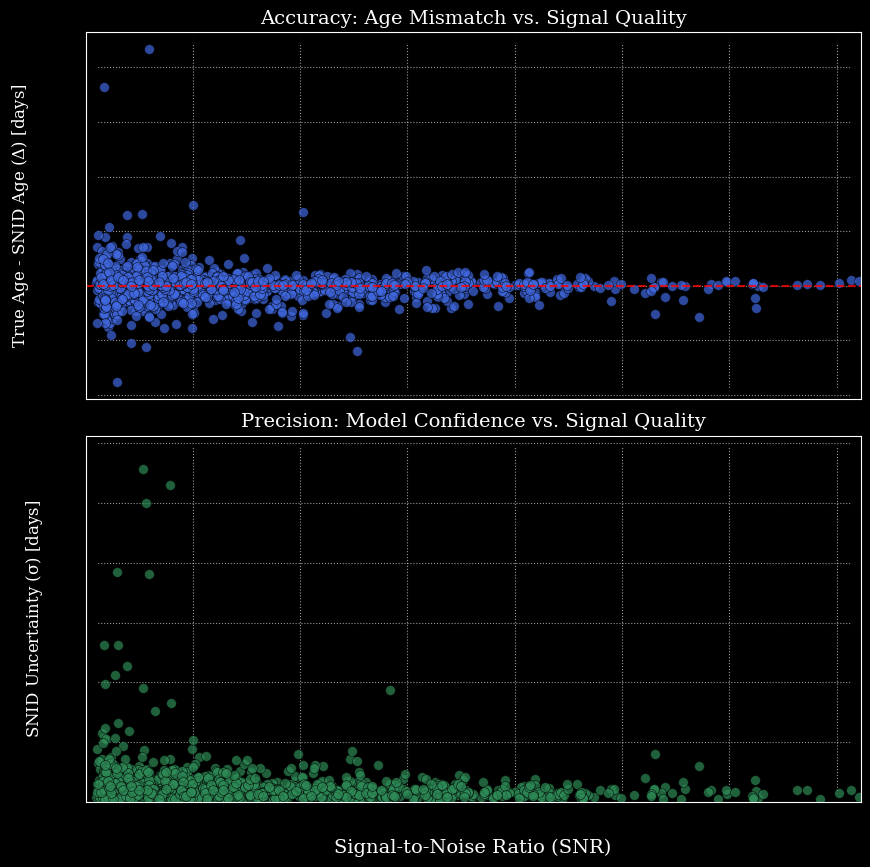

In [51]:
OUTPUT_PLOT_FILE_SNR = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_snr.png'

# 1. Prepare Data
# Use merged_df to see the full distribution, including outliers at low SNR
plot_snr_df = merged_df.copy()
plot_snr_df.dropna(subset=['snr', 'delta', 'std_dev'], inplace=True)

# Optional: Cut off extremely high SNR outliers for better plotting if needed
# plot_snr_df = plot_snr_df[plot_snr_df['snr'] < 100]

# 2. Setup Plot
try:
    plt.style.use('GausSN.mplstyle')
except OSError:
    print("Style not found, using default.")

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
plt.subplots_adjust(hspace=0.1) # Reduce gap between plots

# -----------------------------
# Panel 1: Accuracy (Delta vs SNR)
# -----------------------------
axes[0].scatter(
    plot_snr_df['snr'],
    plot_snr_df['delta'],
    c='royalblue',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=50,
    label='Residuals'
)

axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel(r"True Age - SNID Age ($\Delta$) [days]", fontsize=12)
axes[0].set_title("Accuracy: Age Mismatch vs. Signal Quality", fontsize=14)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Add standard deviation bounds as a guide?
# axes[0].axhline(2, color='gray', linestyle=':', alpha=0.5)
# axes[0].axhline(-2, color='gray', linestyle=':', alpha=0.5)


# -----------------------------
# Panel 2: Precision (Sigma vs SNR)
# -----------------------------
axes[1].scatter(
    plot_snr_df['snr'],
    plot_snr_df['std_dev'],
    c='seagreen',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=50,
    label='Uncertainty'
)

axes[1].set_ylabel(r"SNID Uncertainty ($\sigma$) [days]", fontsize=12)
axes[1].set_xlabel("Signal-to-Noise Ratio (SNR)", fontsize=14)
axes[1].set_title("Precision: Model Confidence vs. Signal Quality", fontsize=14)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Set logical limits
# Assuming SNR goes from 0 to ~50 or 100
max_snr = np.percentile(plot_snr_df['snr'], 99) * 1.1 # 99th percentile to ignore extreme outliers
axes[1].set_xlim(0, max_snr)
# axes[1].set_xlim(0, 10)

axes[1].set_ylim(0, np.max(plot_snr_df['std_dev']) * 1.1)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_SNR, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE_SNR}")

plt.show()

Plot saved successfully to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_age_vs_true_age.png


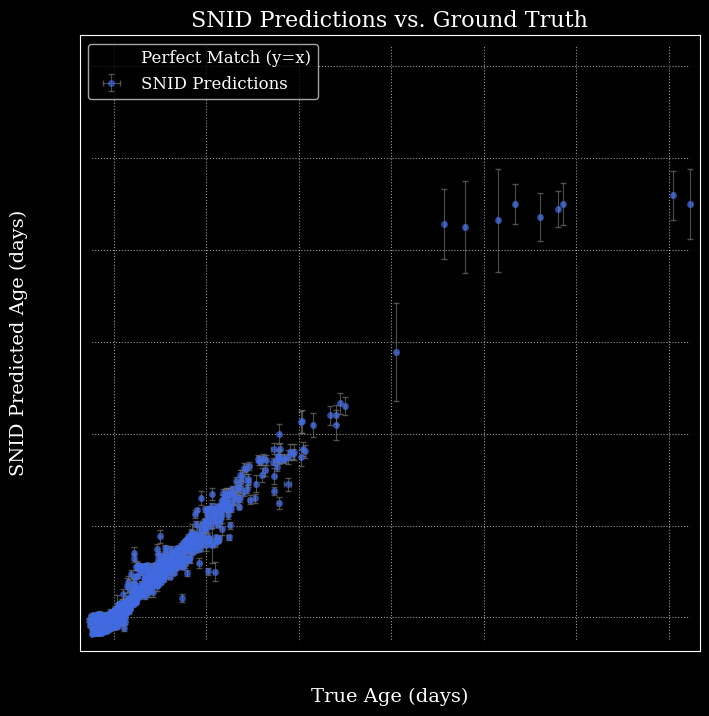

In [52]:
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_PLOT_FILE_AGE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_age_vs_true_age.png'

# 1. Prepare Data
plot_age_df = merged_df.copy()
# Drop NaNs in the columns we need to plot
plot_age_df.dropna(subset=['true_age', 'bootstrap_age', 'std_dev', 'true_age_err'], inplace=True)

# 2. Setup Plot
try:
    plt.style.use('GausSN.mplstyle')
except OSError:
    print("Style not found, using default.")

fig_age, ax_age = plt.subplots(figsize=(8, 8)) # Square figure for 1:1 comparison

# 3. Plot the 1:1 Diagonal Line (Perfect Agreement)
# Get min and max to draw the line across the whole range
line_min = min(plot_age_df['true_age'].min(), plot_age_df['bootstrap_age'].min()) - 5
line_max = max(plot_age_df['true_age'].max(), plot_age_df['bootstrap_age'].max()) + 5

ax_age.plot([line_min, line_max], [line_min, line_max],
            color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Perfect Match (y=x)')

# 4. Scatter Plot with Error Bars
# We use 'errorbar' instead of 'scatter' to show uncertainties
ax_age.errorbar(
    plot_age_df['true_age'],
    plot_age_df['bootstrap_age'],
    yerr=plot_age_df['std_dev'],       # SNID uncertainty
    xerr=plot_age_df['true_age_err'],  # True Age uncertainty
    fmt='o',             # Markers only (no connecting lines)
    c='royalblue',       # Color
    ecolor='gray',       # Error bar color (lighter)
    elinewidth=0.8,      # Error bar width
    capsize=2,           # End caps on error bars
    alpha=0.6,           # Transparency
    markersize=4,
    label='SNID Predictions'
)

# 5. Labels and Titles
ax_age.set_xlabel("True Age (days)", fontsize=14)
ax_age.set_ylabel("SNID Predicted Age (days)", fontsize=14)
ax_age.set_title("SNID Predictions vs. Ground Truth", fontsize=16)

# 6. Formatting
ax_age.set_xlim(line_min, line_max)
ax_age.set_ylim(line_min, line_max)
ax_age.grid(True, linestyle=':', alpha=0.6)
ax_age.legend(loc='upper left', fontsize=12)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_AGE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {OUTPUT_PLOT_FILE_AGE}")

plt.show()

Plotting 1418 points after filtering.
Plot saved to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snr_vs_true_age.png


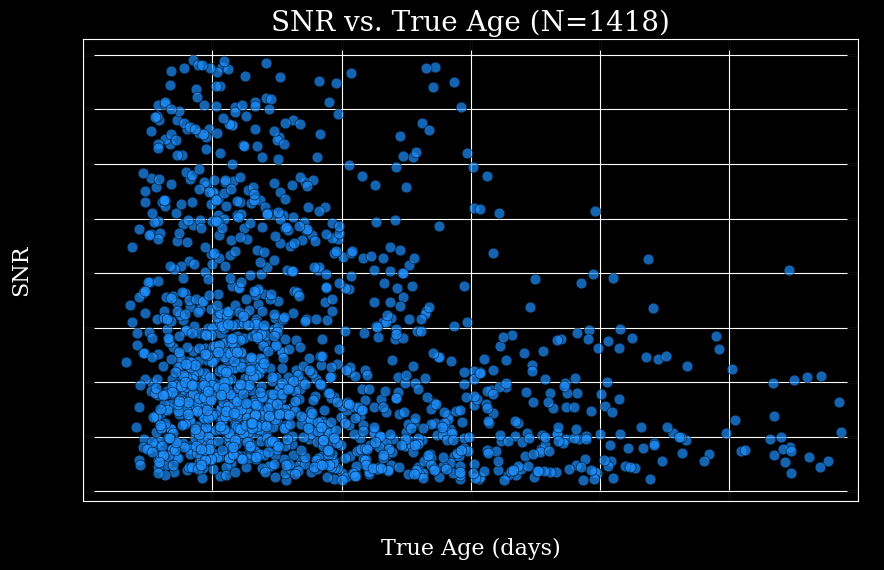

In [53]:
OUTPUT_PLOT_FILE_SNR_AGE = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snr_vs_true_age.png'

# 1. Prepare Data
plot_snr_age_df = merged_df.copy()

# 2. Ensure Numeric Columns
cols_to_check = ['true_age', 'snr']
for c in cols_to_check:
    plot_snr_age_df[c] = pd.to_numeric(plot_snr_age_df[c], errors='coerce')

# 3. Apply Quality Cuts (SNR >= 5)
plot_snr_age_df = plot_snr_age_df[plot_snr_age_df['snr'] <= 200]

# 4. Drop Missing Data
plot_snr_age_df.dropna(subset=['true_age', 'snr'], inplace=True)

print(f"Plotting {len(plot_snr_age_df)} points after filtering.")

# 5. Plotting
plt.style.use('GausSN.mplstyle') # Ensure this file exists
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter Plot
ax.scatter(
    plot_snr_age_df['true_age'], # X-axis
    plot_snr_age_df['snr'],      # Y-axis
    c='dodgerblue',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
    s=60,
    label='Data'
)

# Labels and Title
ax.set_xlabel("True Age (days)")
ax.set_ylabel("SNR")
ax.set_title(f"SNR vs. True Age (N={len(plot_snr_age_df)})")
ax.set_xlim(-20, 100)
# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_SNR_AGE, dpi=300, bbox_inches='tight')
print(f"Plot saved to {OUTPUT_PLOT_FILE_SNR_AGE}")

plt.show()

Plotting 1151 points.
Plot saved to /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_true_age_snr_colored.png


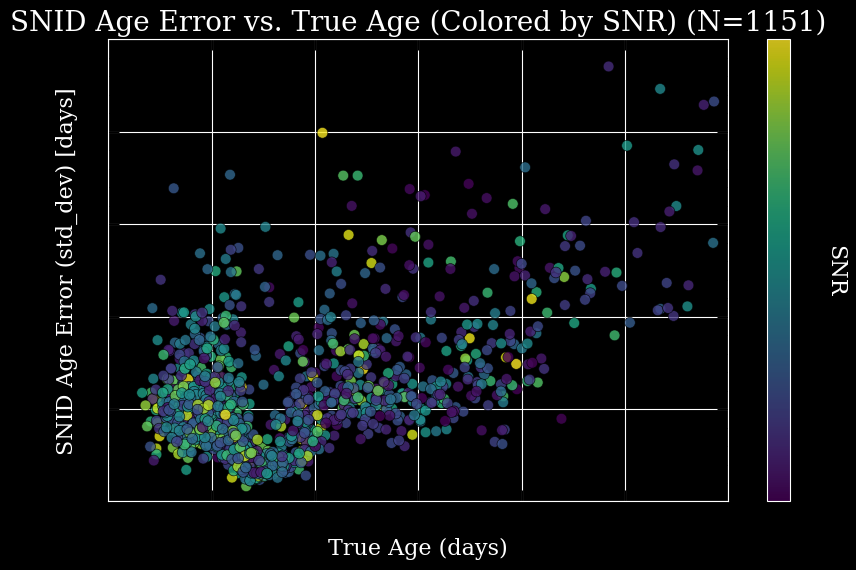

In [54]:
OUTPUT_PLOT_FILE_ERROR_VS_AGE_SNR = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/snid_error_vs_true_age_snr_colored.png'

# 1. Prepare Data
plot_error_age_df = merged_df.copy()

# 2. Ensure Numeric Columns
cols_to_check = ['true_age', 'std_dev', 'snr']
for c in cols_to_check:
    plot_error_age_df[c] = pd.to_numeric(plot_error_age_df[c], errors='coerce')

# 3. Apply Quality Cuts (SNR >= 5)
plot_error_age_df = plot_error_age_df[plot_error_age_df['snr'] <= 100]

# 4. Drop Missing Data
plot_error_age_df.dropna(subset=['true_age', 'std_dev', 'snr'], inplace=True)

print(f"Plotting {len(plot_error_age_df)} points.")

# 5. Plotting
plt.style.use('GausSN.mplstyle')
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter Plot with Colorbar
sc = ax.scatter(
    plot_error_age_df['true_age'], # X-axis
    plot_error_age_df['std_dev'],  # Y-axis
    c=plot_error_age_df['snr'],    # Color dimension
    cmap='viridis',
    alpha=0.8,
    edgecolors='k',
    linewidth=0.5,
    s=60,
    label='Data'
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("SNR", rotation=270, labelpad=15)

# Labels and Title
ax.set_xlabel("True Age (days)")
ax.set_ylabel("SNID Age Error (std_dev) [days]")
ax.set_title(f"SNID Age Error vs. True Age (Colored by SNR) (N={len(plot_error_age_df)})")

# Set Limits
ax.set_xlim(-20, 100)
ax.set_ylim(0, 5)

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_ERROR_VS_AGE_SNR, dpi=300, bbox_inches='tight')
print(f"Plot saved to {OUTPUT_PLOT_FILE_ERROR_VS_AGE_SNR}")

plt.show()

Correlation Matrix:
               true_age  true_age_err       snr  bootstrap_age   std_dev  \
true_age       1.000000      0.025986 -0.231143       0.982417  0.672449   
true_age_err   0.025986      1.000000 -0.027523       0.017295 -0.002636   
snr           -0.231143     -0.027523  1.000000      -0.230926 -0.136738   
bootstrap_age  0.982417      0.017295 -0.230926       1.000000  0.680889   
std_dev        0.672449     -0.002636 -0.136738       0.680889  1.000000   
delta          0.358178      0.050481 -0.063553       0.177566  0.139518   
total_error    0.662312      0.160595 -0.141519       0.668795  0.984228   
dm15          -0.085965     -0.171870 -0.082256      -0.049751  0.019165   

                  delta  total_error      dm15  
true_age       0.358178     0.662312 -0.085965  
true_age_err   0.050481     0.160595 -0.171870  
snr           -0.063553    -0.141519 -0.082256  
bootstrap_age  0.177566     0.668795 -0.049751  
std_dev        0.139518     0.984228  0.019165  
d

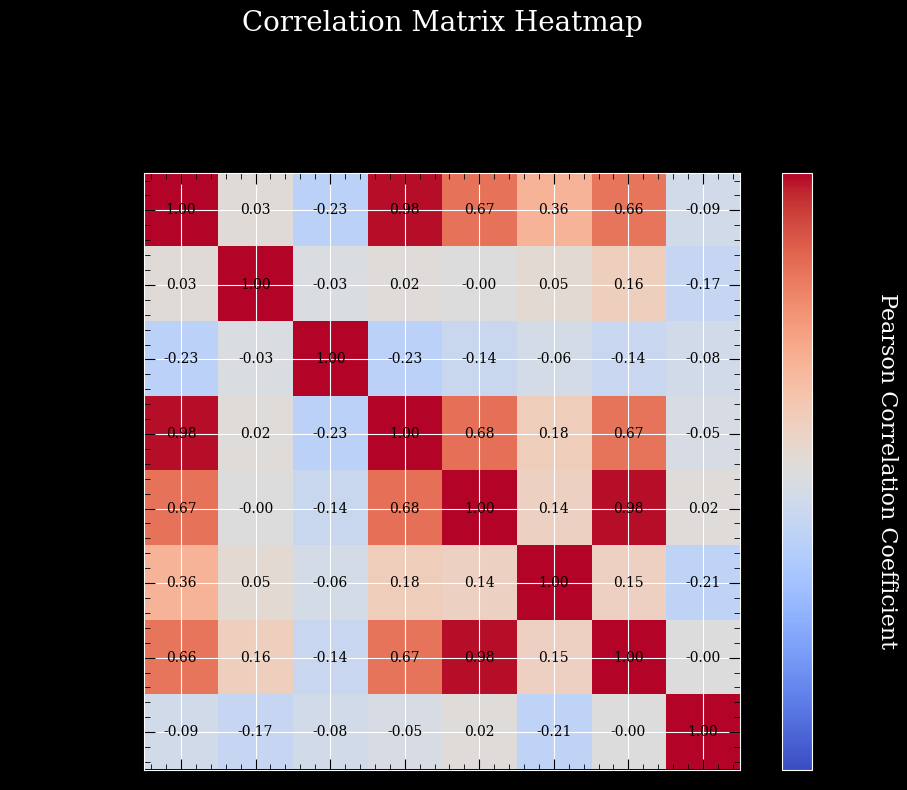

In [55]:
OUTPUT_PLOT_FILE_CORR = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/correlation_matrix.png'

# 1. Prepare Data
corr_df = merged_df.copy()

# 2. Select only numeric columns
# This automatically drops columns like 'spectrum_filename', 'sn_name', 'subtype'
numeric_df = corr_df.select_dtypes(include=[np.number])

# 3. Calculate Correlation Matrix
corr_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(corr_matrix)

# 4. Plotting the Heatmap
# plt.style.use('GausSN.mplstyle') # Uncomment if style file is present
fig, ax = plt.subplots(figsize=(10, 8))

# Use matshow to display the matrix
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add Colorbar
cbar = fig.colorbar(cax)
cbar.set_label("Pearson Correlation Coefficient", rotation=270, labelpad=15)

# Set ticks and labels
ticks = np.arange(len(corr_matrix.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Rotate x-axis labels for readability
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

# Add numeric values to the cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black", fontsize=10)

ax.set_title("Correlation Matrix Heatmap")
plt.tight_layout() # Adjust layout to ensure labels are not cut off

# Save and Show
plt.savefig(OUTPUT_PLOT_FILE_CORR, dpi=300, bbox_inches='tight')
print(f"Plot saved to {OUTPUT_PLOT_FILE_CORR}")

plt.show()

In [56]:
OUTPUT_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/binned_correlations/'

# Create directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Prepare Data
stats_df = merged_df.copy()

# Handle potential column name differences (mean_age vs bootstrap_age)
if 'bootstrap_age' not in stats_df.columns and 'mean_age' in stats_df.columns:
    stats_df['bootstrap_age'] = stats_df['mean_age']

# Columns to include in the correlation analysis
cols_of_interest = ['true_age', 'bootstrap_age', 'delta', 'total_error', 'snr', 'std_dev']
# Filter only those that actually exist in the dataframe
cols_to_use = [c for c in cols_of_interest if c in stats_df.columns]

# Ensure Numeric Columns
for c in cols_to_use:
    stats_df[c] = pd.to_numeric(stats_df[c], errors='coerce')

# 3. Create Bins (10-day intervals)
# Define bins from the minimum age (rounded down) to maximum age (rounded up)
min_age = np.floor(stats_df['true_age'].min() / 10) * 10
max_age = np.ceil(stats_df['true_age'].max() / 10) * 10
bins = np.arange(min_age, max_age + 10, 10)

stats_df['age_bin'] = pd.cut(stats_df['true_age'], bins=bins)

# 4. Iterate through bins and plot Correlation Matrix for each
print(f"Generating correlation matrices in: {OUTPUT_DIR}")

# Group by the bin
groups = stats_df.groupby('age_bin')

for interval, bin_data in groups:
    # Skip bins with insufficient data for correlation (need at least 2 points)
    if len(bin_data) < 2:
        continue

    # Calculate Correlation
    # We use only the numeric columns of interest
    corr_matrix = bin_data[cols_to_use].corr()

    # Check if correlation matrix is valid (not all NaNs)
    if corr_matrix.isna().all().all():
        continue

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 8))

    # Heatmap
    cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

    # Add Colorbar
    cbar = fig.colorbar(cax)
    cbar.set_label("Pearson Correlation Coefficient", rotation=270, labelpad=15)

    # Ticks and Labels
    ticks = np.arange(len(corr_matrix.columns))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(corr_matrix.columns, rotation=90)
    ax.set_yticklabels(corr_matrix.columns)

    # Annotate with values
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            val = corr_matrix.iloc[i, j]
            text_val = f"{val:.2f}" if not np.isnan(val) else "NaN"
            ax.text(j, i, text_val, ha="center", va="center", color="black", fontsize=9)

    # Title with Bin Range and Count
    bin_label_str = f"{interval.left} to {interval.right} days"
    ax.set_title(f"Correlation Matrix\nBin: {bin_label_str} (N={len(bin_data)})")

    # Save File
    # Create a safe filename
    safe_interval_name = f"{int(interval.left)}_{int(interval.right)}"
    filename = f"corr_matrix_bin_{safe_interval_name}.png"
    save_path = os.path.join(OUTPUT_DIR, filename)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close to free memory

    print(f"Saved: {filename}")

print("\nProcessing complete.")

Generating correlation matrices in: /Users/pxm588@student.bham.ac.uk/PhD/SNID_pipelines/cfa_bootstrap_tests/binned_correlations/


/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_68014/963975790.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = stats_df.groupby('age_bin')


Saved: corr_matrix_bin_-20_-10.png
Saved: corr_matrix_bin_-10_0.png
Saved: corr_matrix_bin_0_10.png
Saved: corr_matrix_bin_10_20.png
Saved: corr_matrix_bin_20_30.png
Saved: corr_matrix_bin_30_40.png
Saved: corr_matrix_bin_40_50.png
Saved: corr_matrix_bin_50_60.png
Saved: corr_matrix_bin_60_70.png
Saved: corr_matrix_bin_70_80.png
Saved: corr_matrix_bin_80_90.png
Saved: corr_matrix_bin_90_100.png
Saved: corr_matrix_bin_100_110.png
Saved: corr_matrix_bin_120_130.png
Saved: corr_matrix_bin_240_250.png

Processing complete.
